In [2]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
import xarray as xr
import os
import glob
# import seaborn as sns
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator
import matplotlib
from phd_clouds.utils import get_complete_time, assign_season, reading_dataset_chunking

In [3]:
%matplotlib inline
# %matplotlib widget
# Define here plot configuration
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 1
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['axes.titlepad'] = 20  # Raise title
# sans serif
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [4]:
filepath_data = "/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_analysis/cloud_properties" # Path to save the cloud classification files
filepath_cloud_occurence = "/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_analysis/cloud_occurrence" # Path to save the cloud classification files
filepath_cloud_cloud_type = "/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_analysis/cloud_type" 
filepath_cloud_duration = "/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_analysis/time_duration_cloud_type"
figure_path = "/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_figures"

# Case by case analysis of total change in frequency and cloud properties

In [4]:
pattern = "*min_ice_percentage.nc"
filenames_occurence  = glob.glob(os.path.join(filepath_cloud_occurence, pattern))
filenames_cloud_type = glob.glob(os.path.join(filepath_cloud_cloud_type, pattern))
filenames_properties = glob.glob(os.path.join(filepath_data, pattern))

In [ ]:
# This will combine all files along the 'time' dimension by default
ds_occurence  = xr.open_mfdataset(filenames_occurence, combine='by_coords').compute()
ds_cloud_type = xr.open_mfdataset(filenames_cloud_type, combine='by_coords').compute()
ds_properties = xr.open_mfdataset(filenames_properties, combine='by_coords').compute()

In [ ]:
ds_properties.head

<bound method Dataset.head of <xarray.Dataset>
Dimensions:             (time: 3976104, min_ice_percentage: 9)
Coordinates:
  * time                (time) datetime64[ns] 2018-04-23T15:28:45.001144409 ....
  * min_ice_percentage  (min_ice_percentage) int64 60 65 70 75 80 85 90 95 100
Data variables:
    cloud_base          (time, min_ice_percentage) float64 4.474e+03 ... 5.37...
    cloud_top           (time, min_ice_percentage) float64 5.772e+03 ... 1.10...
    cloud_thickness     (time, min_ice_percentage) float64 1.298e+03 ... 5.66...
    lwp                 (time, min_ice_percentage) float64 nan nan ... nan nan>

In [ ]:
cloud_type_str = 'Precipitating-Mixed-Phase'
mask_prop  =(ds_occurence.single_layer == 1 ) & (ds_occurence.attenuation == False) & (ds_cloud_type[cloud_type_str] == 1.)
mask_occur =(ds_cloud_type[cloud_type_str] == 1.)
ds_properties_filtered = ds_properties.where(mask_prop)
ds_occurence_filtered  = ds_occurence.where(mask_occur, 0)

### Statistics

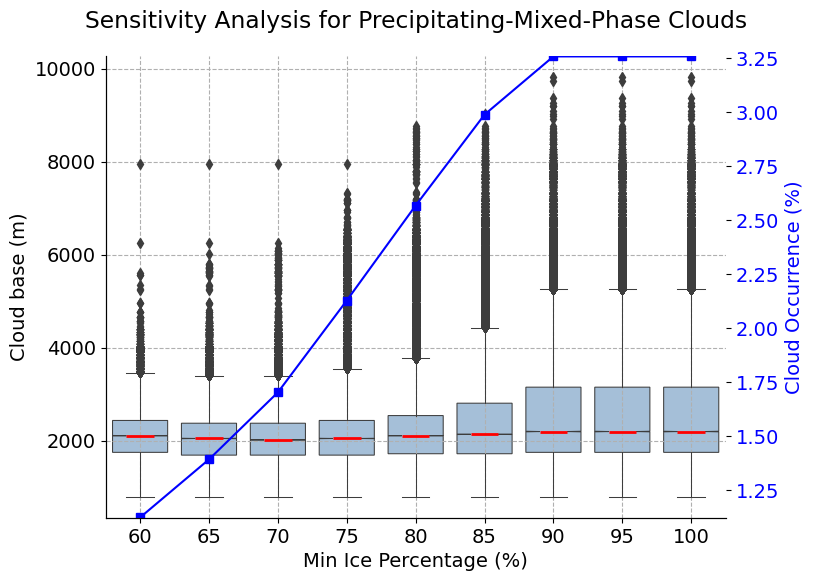

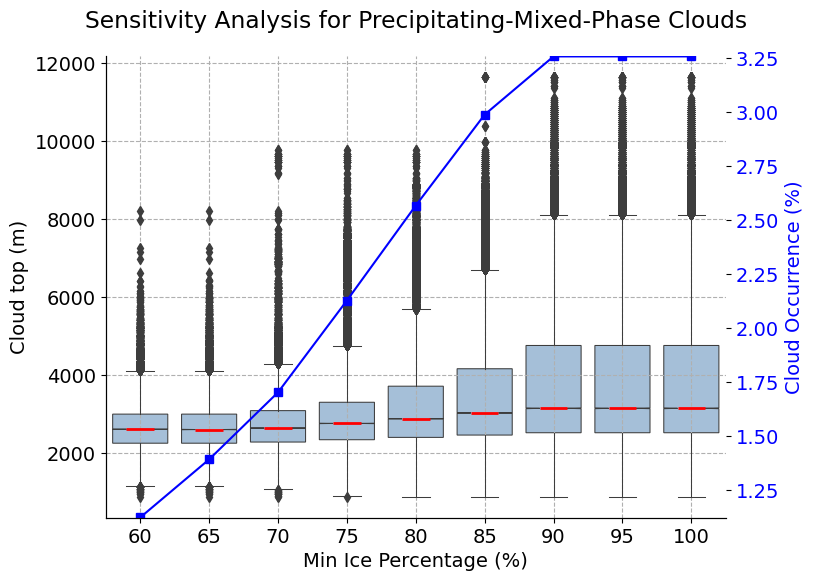

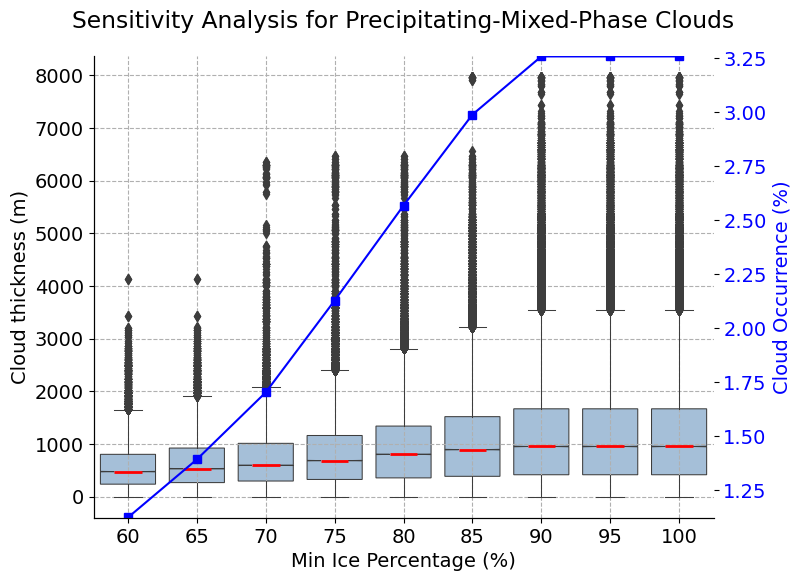

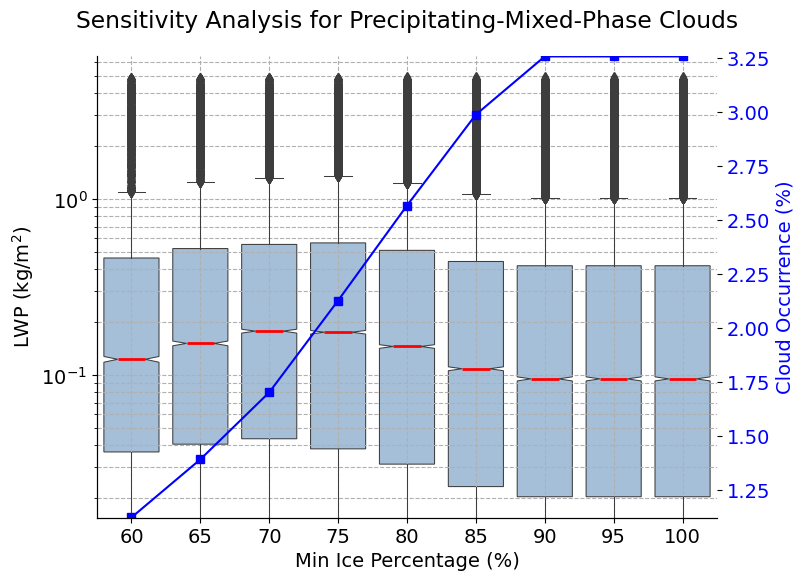

In [ ]:
plt.close('all')
data_vars = list(ds_properties_filtered.data_vars)
parameter_names = {'min_liquid_percentage': 'Min Liquid Percentage (%)',
                  'min_ice_percentage': 'Min Ice Percentage (%)',
                  'min_cloudp': 'Min Number of Cloud Pixels (#)',
                  'min_rainp': 'Min Rain Pixels (#)'
                  }
freq_occur   = ds_occurence_filtered['single_layer'].mean(dim='time')*100
number_occur = ds_occurence_filtered['single_layer'].sum(dim='time')
for var in data_vars:
    fig, ax = plt.subplots(figsize=(8,6))
    # plot boxplot for each min_cloudp
    sns.boxplot(x=pattern[1:-3], y=var, 
                data=ds_properties_filtered.to_dataframe().reset_index(),
                notch=True,
                boxprops={"facecolor": (.3, .5, .7, .5)},
                linewidth=.75,
                medianprops={"color": "r", "linewidth": 2}, 
                ax=ax)
    if var == 'lwp':
        ax.set_yscale('log')
        # let all CAPITAL
        ax.set_ylabel(var.replace('_', ' ').upper() + r' (kg/m$^2$)')
    else:
        ax.set_ylabel(var.replace('_', ' ').capitalize() + ' (m)')
    ax.grid(True, which="both", ls="--")
    ax.set_xlabel(parameter_names[pattern[1:-3]])

    ax2 = ax.twinx()
    ax2.plot(freq_occur, color='blue', marker='s', linestyle='-')
    ax2.set_ylabel('Cloud Occurrence (%)', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.set_ylim(freq_occur.min()*0.999, freq_occur.max()*1.001)
    ax2.grid(False)

    # remove top end right spines
    ax.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # ax3 = ax.twinx() # Plot number_occur
    # ax3.spines['right'].set_position(('outward', 60))  #
    # ax3.plot(number_occur, color='green', marker='o', linestyle='--')
    # ax3.set_ylabel('Number of Occurrences', color='green')
    # ax3.tick_params(axis='y', labelcolor='green')
    # ax3.set_ylim(number_occur.min()*0.9, number_occur.max()*1.1)
    # ax3.grid(False)

    plt.title(f'Sensitivity Analysis for {cloud_type_str} Clouds')
    plt.show()


# Pertubation analysis:
## Seasonal Analysis for all parameters (reduced)

Liquid - Total occurrence Variation between min_cloudp (60, 140): 0.35%
Precipitating-Liquid - Total occurrence Variation between min_cloudp (60, 140): -0.02%
Ice - Total occurrence Variation between min_cloudp (60, 140): 0.16%
Precipitating-Ice - Total occurrence Variation between min_cloudp (60, 140): -0.09%
Mixed-Phase - Total occurrence Variation between min_cloudp (60, 140): 0.08%
Precipitating-Mixed-Phase - Total occurrence Variation between min_cloudp (60, 140): -0.07%


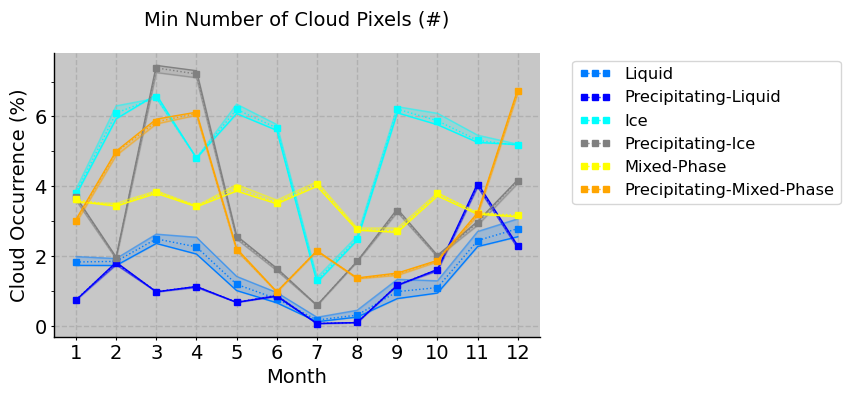

Liquid - Total cloud_base Variation between min_cloudp (60, 140): -29.81
Precipitating-Liquid - Total cloud_base Variation between min_cloudp (60, 140): 0.00
Ice - Total cloud_base Variation between min_cloudp (60, 140): -102.21
Precipitating-Ice - Total cloud_base Variation between min_cloudp (60, 140): 0.70
Mixed-Phase - Total cloud_base Variation between min_cloudp (60, 140): -51.14
Precipitating-Mixed-Phase - Total cloud_base Variation between min_cloudp (60, 140): 19.42


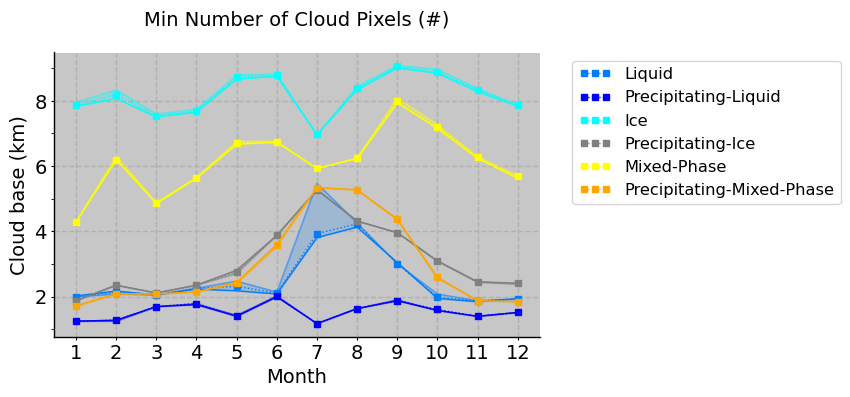

Liquid - Total cloud_thickness Variation between min_cloudp (60, 140): 29.81
Precipitating-Liquid - Total cloud_thickness Variation between min_cloudp (60, 140): 0.00
Ice - Total cloud_thickness Variation between min_cloudp (60, 140): 123.38
Precipitating-Ice - Total cloud_thickness Variation between min_cloudp (60, 140): -34.21
Mixed-Phase - Total cloud_thickness Variation between min_cloudp (60, 140): 34.07
Precipitating-Mixed-Phase - Total cloud_thickness Variation between min_cloudp (60, 140): -12.39


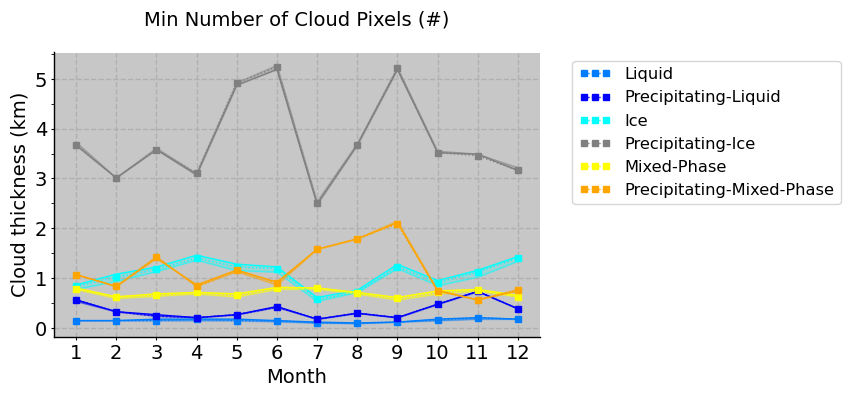

Liquid - Total cloud_lwp Variation between min_cloudp (60, 140): 0.00
Precipitating-Liquid - Total cloud_lwp Variation between min_cloudp (60, 140): 0.00
Mixed-Phase - Total cloud_lwp Variation between min_cloudp (60, 140): 0.00
Precipitating-Mixed-Phase - Total cloud_lwp Variation between min_cloudp (60, 140): -0.00


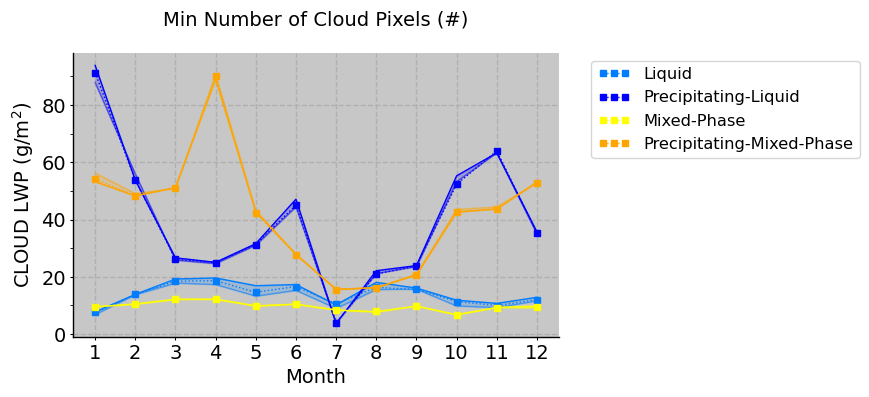

Ice - Total cloud_iwp Variation between min_cloudp (60, 140): 0.00
Precipitating-Ice - Total cloud_iwp Variation between min_cloudp (60, 140): -0.00
Mixed-Phase - Total cloud_iwp Variation between min_cloudp (60, 140): 0.00
Precipitating-Mixed-Phase - Total cloud_iwp Variation between min_cloudp (60, 140): 0.00


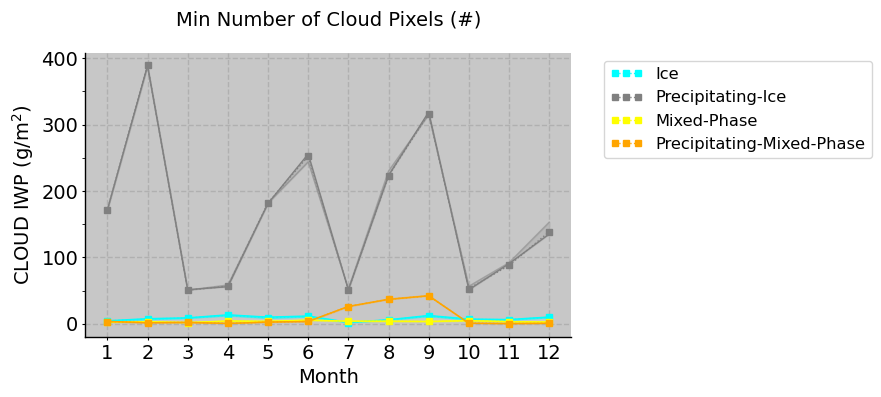

Liquid - Total occurrence Variation between min_liquid_percentage (60, 90): 0.57%
Precipitating-Liquid - Total occurrence Variation between min_liquid_percentage (60, 90): 0.61%
Ice - Total occurrence Variation between min_liquid_percentage (60, 90): 0.00%
Precipitating-Ice - Total occurrence Variation between min_liquid_percentage (60, 90): -0.00%
Mixed-Phase - Total occurrence Variation between min_liquid_percentage (60, 90): -0.57%
Precipitating-Mixed-Phase - Total occurrence Variation between min_liquid_percentage (60, 90): -0.62%


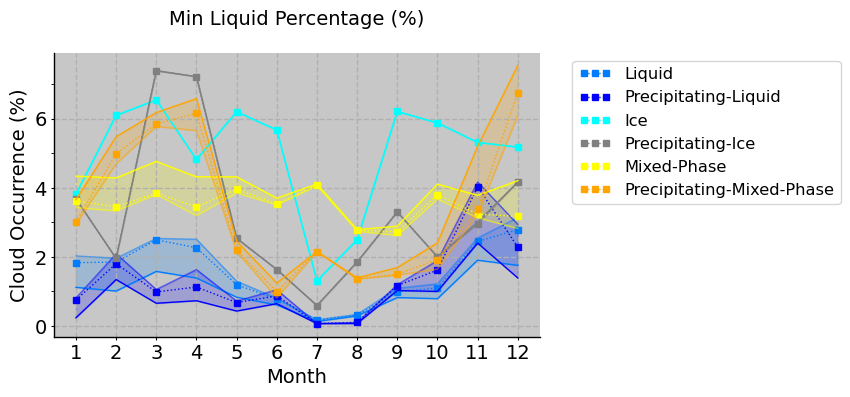

Liquid - Total cloud_base Variation between min_liquid_percentage (60, 90): -119.24
Precipitating-Liquid - Total cloud_base Variation between min_liquid_percentage (60, 90): -89.44
Ice - Total cloud_base Variation between min_liquid_percentage (60, 90): 0.00
Precipitating-Ice - Total cloud_base Variation between min_liquid_percentage (60, 90): 0.00
Mixed-Phase - Total cloud_base Variation between min_liquid_percentage (60, 90): -343.20
Precipitating-Mixed-Phase - Total cloud_base Variation between min_liquid_percentage (60, 90): -33.28


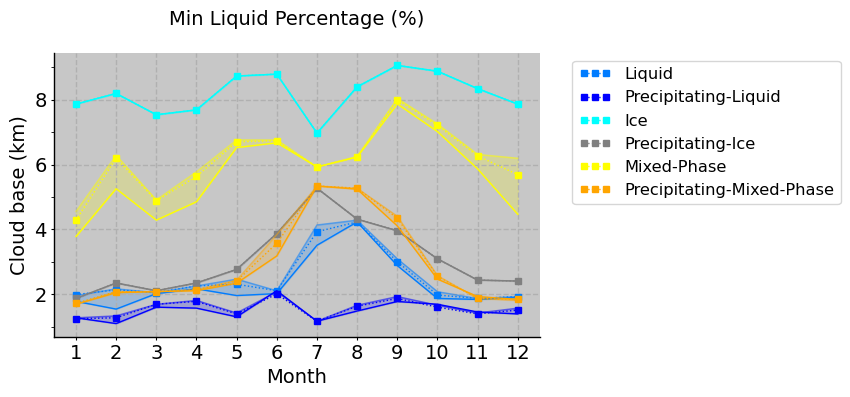

Liquid - Total cloud_thickness Variation between min_liquid_percentage (60, 90): -17.33
Precipitating-Liquid - Total cloud_thickness Variation between min_liquid_percentage (60, 90): -38.13
Ice - Total cloud_thickness Variation between min_liquid_percentage (60, 90): 0.00
Precipitating-Ice - Total cloud_thickness Variation between min_liquid_percentage (60, 90): -0.00
Mixed-Phase - Total cloud_thickness Variation between min_liquid_percentage (60, 90): -119.25
Precipitating-Mixed-Phase - Total cloud_thickness Variation between min_liquid_percentage (60, 90): -149.06


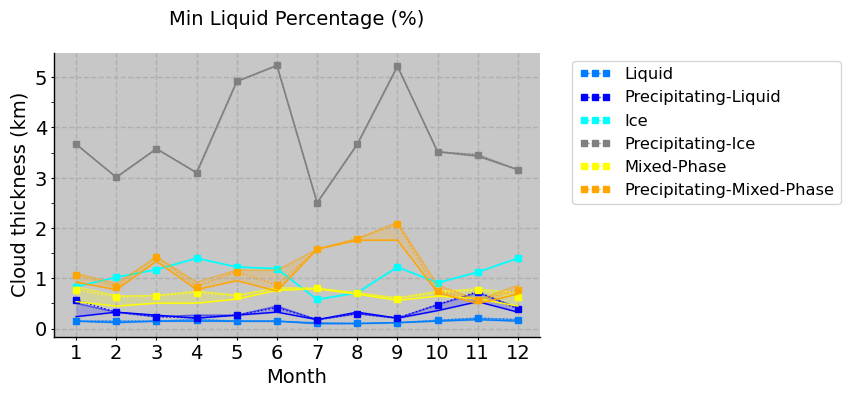

Liquid - Total cloud_lwp Variation between min_liquid_percentage (60, 90): -0.00
Precipitating-Liquid - Total cloud_lwp Variation between min_liquid_percentage (60, 90): -0.00
Mixed-Phase - Total cloud_lwp Variation between min_liquid_percentage (60, 90): 0.00
Precipitating-Mixed-Phase - Total cloud_lwp Variation between min_liquid_percentage (60, 90): -0.00


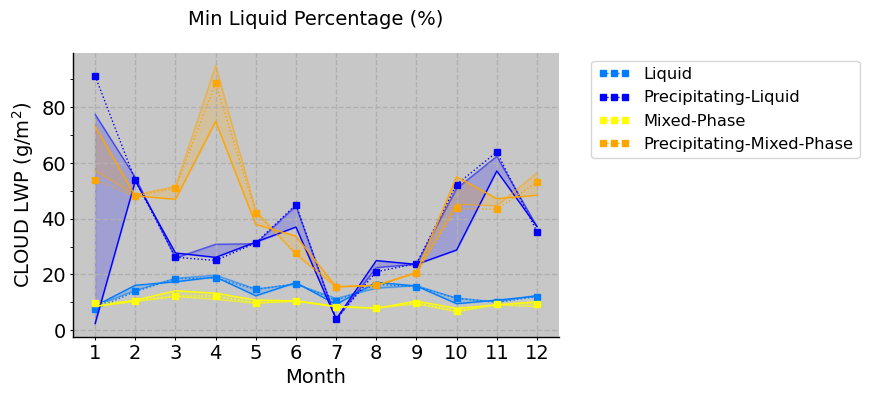

Ice - Total cloud_iwp Variation between min_liquid_percentage (60, 90): 0.00
Precipitating-Ice - Total cloud_iwp Variation between min_liquid_percentage (60, 90): -0.00
Mixed-Phase - Total cloud_iwp Variation between min_liquid_percentage (60, 90): -0.00
Precipitating-Mixed-Phase - Total cloud_iwp Variation between min_liquid_percentage (60, 90): -0.00


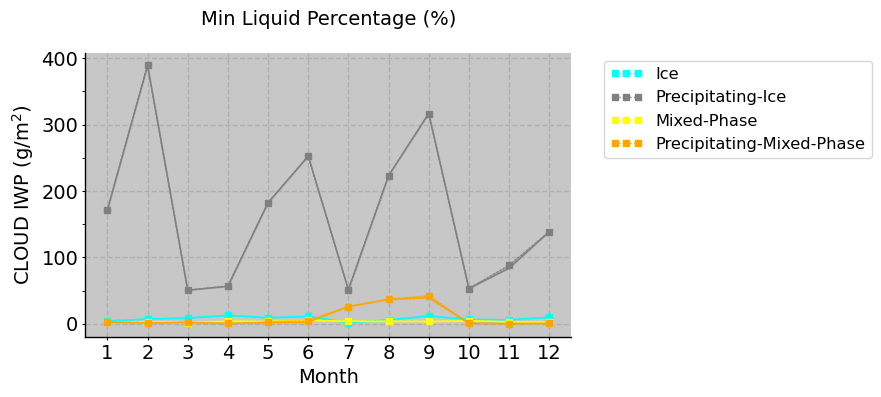

Liquid - Total occurrence Variation between min_ice_percentage (80, 100): 0.00%
Precipitating-Liquid - Total occurrence Variation between min_ice_percentage (80, 100): 0.00%
Ice - Total occurrence Variation between min_ice_percentage (80, 100): 1.44%
Precipitating-Ice - Total occurrence Variation between min_ice_percentage (80, 100): 0.64%
Mixed-Phase - Total occurrence Variation between min_ice_percentage (80, 100): -1.46%
Precipitating-Mixed-Phase - Total occurrence Variation between min_ice_percentage (80, 100): -0.68%


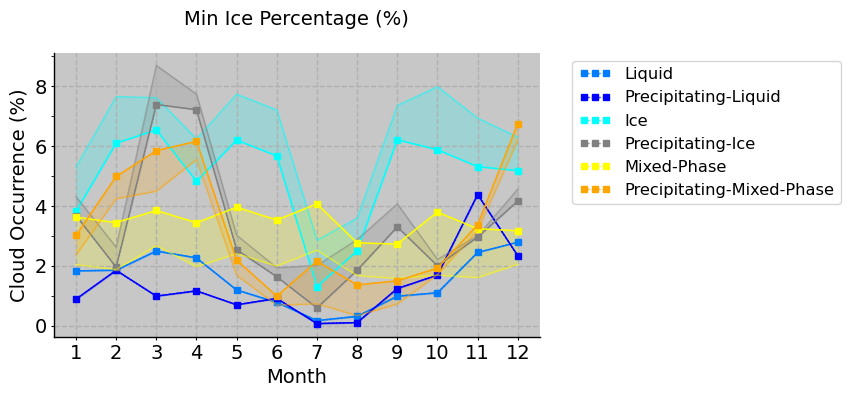

Liquid - Total cloud_base Variation between min_ice_percentage (80, 100): 0.00
Precipitating-Liquid - Total cloud_base Variation between min_ice_percentage (80, 100): 0.00
Ice - Total cloud_base Variation between min_ice_percentage (80, 100): 272.56
Precipitating-Ice - Total cloud_base Variation between min_ice_percentage (80, 100): -232.25
Mixed-Phase - Total cloud_base Variation between min_ice_percentage (80, 100): 395.37
Precipitating-Mixed-Phase - Total cloud_base Variation between min_ice_percentage (80, 100): 89.44


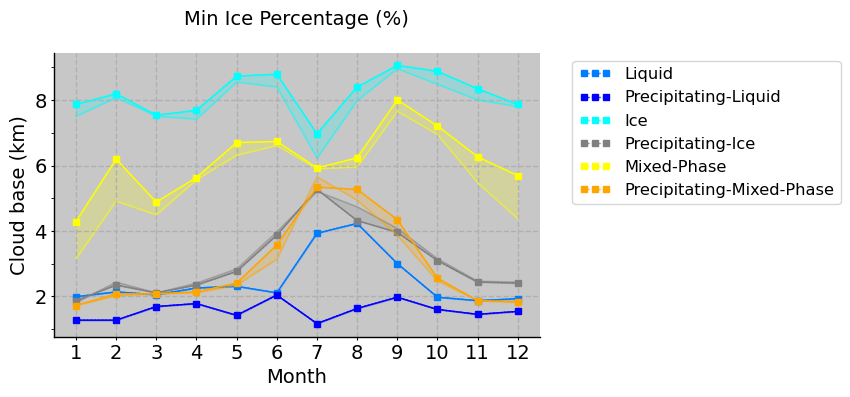

Liquid - Total cloud_thickness Variation between min_ice_percentage (80, 100): 0.00
Precipitating-Liquid - Total cloud_thickness Variation between min_ice_percentage (80, 100): 0.00
Ice - Total cloud_thickness Variation between min_ice_percentage (80, 100): 21.28
Precipitating-Ice - Total cloud_thickness Variation between min_ice_percentage (80, 100): 447.18
Mixed-Phase - Total cloud_thickness Variation between min_ice_percentage (80, 100): 162.23
Precipitating-Mixed-Phase - Total cloud_thickness Variation between min_ice_percentage (80, 100): 149.06


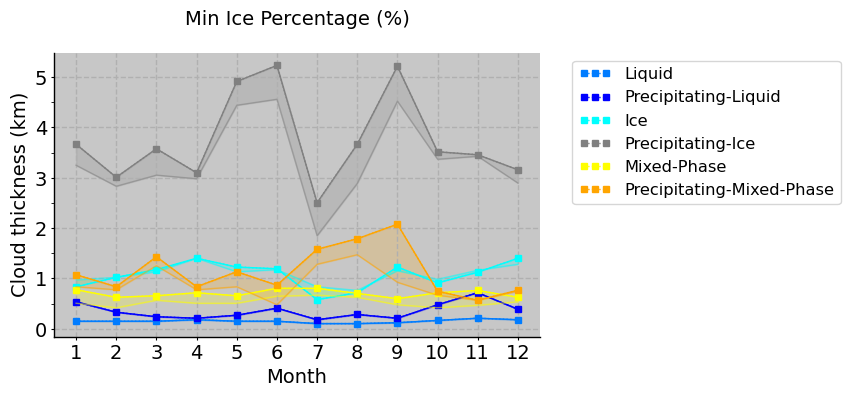

Liquid - Total cloud_lwp Variation between min_ice_percentage (80, 100): 0.00
Precipitating-Liquid - Total cloud_lwp Variation between min_ice_percentage (80, 100): 0.00
Mixed-Phase - Total cloud_lwp Variation between min_ice_percentage (80, 100): -0.00
Precipitating-Mixed-Phase - Total cloud_lwp Variation between min_ice_percentage (80, 100): -0.01


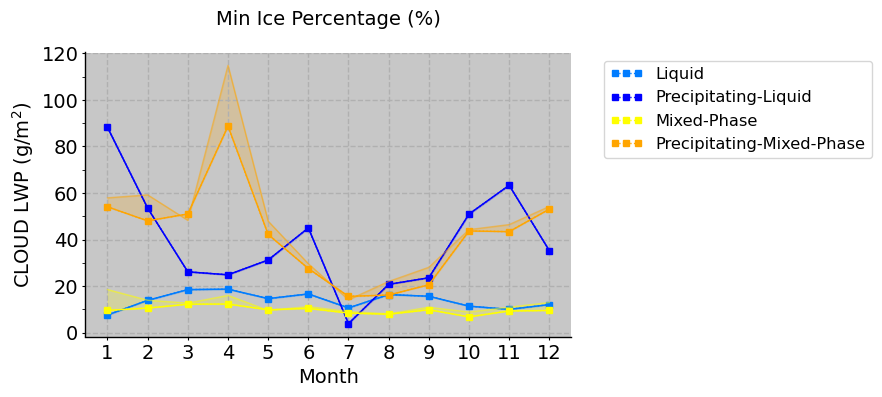

Ice - Total cloud_iwp Variation between min_ice_percentage (80, 100): -0.00
Precipitating-Ice - Total cloud_iwp Variation between min_ice_percentage (80, 100): 0.04
Mixed-Phase - Total cloud_iwp Variation between min_ice_percentage (80, 100): 0.00
Precipitating-Mixed-Phase - Total cloud_iwp Variation between min_ice_percentage (80, 100): 0.00


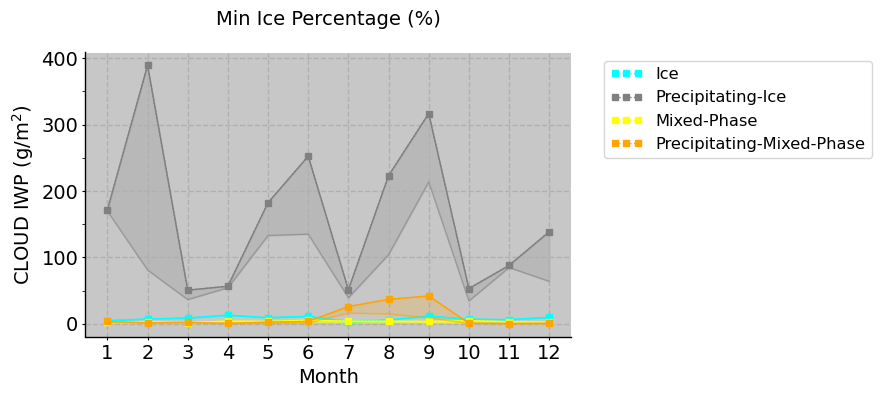

Liquid - Total occurrence Variation between min_rainp (5, 15): -0.16%
Precipitating-Liquid - Total occurrence Variation between min_rainp (5, 15): 0.16%
Ice - Total occurrence Variation between min_rainp (5, 15): -0.00%
Precipitating-Ice - Total occurrence Variation between min_rainp (5, 15): 0.00%
Mixed-Phase - Total occurrence Variation between min_rainp (5, 15): -0.03%
Precipitating-Mixed-Phase - Total occurrence Variation between min_rainp (5, 15): 0.03%


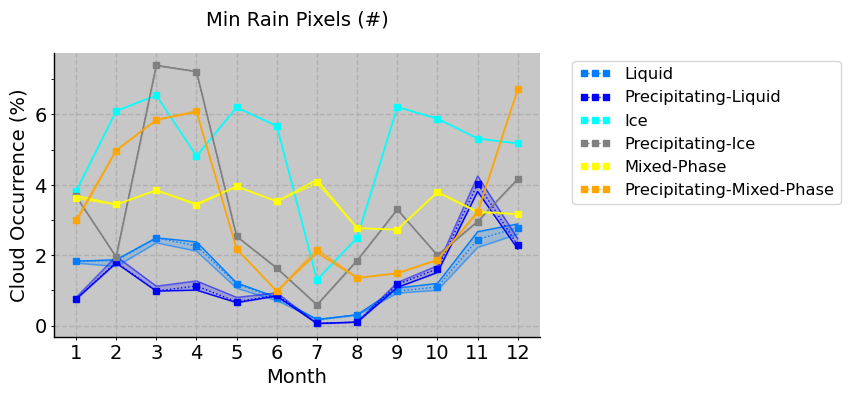

Liquid - Total cloud_base Variation between min_rainp (5, 15): -29.81
Precipitating-Liquid - Total cloud_base Variation between min_rainp (5, 15): 0.00
Ice - Total cloud_base Variation between min_rainp (5, 15): 0.00
Precipitating-Ice - Total cloud_base Variation between min_rainp (5, 15): 0.00
Mixed-Phase - Total cloud_base Variation between min_rainp (5, 15): -21.32
Precipitating-Mixed-Phase - Total cloud_base Variation between min_rainp (5, 15): 0.00


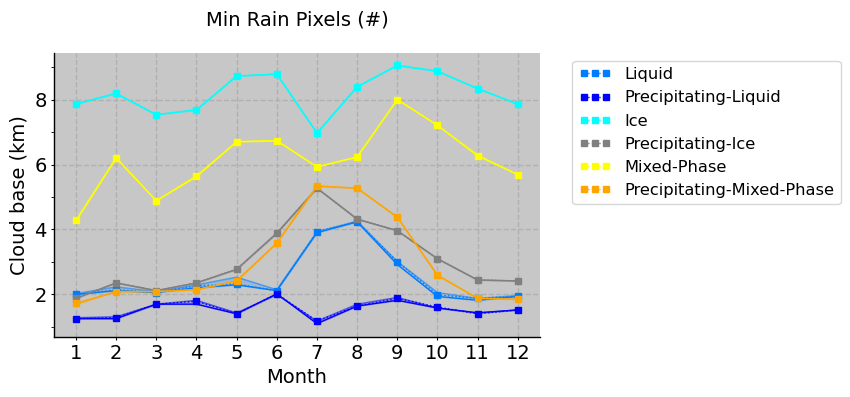

Liquid - Total cloud_thickness Variation between min_rainp (5, 15): 0.00
Precipitating-Liquid - Total cloud_thickness Variation between min_rainp (5, 15): 54.77
Ice - Total cloud_thickness Variation between min_rainp (5, 15): 0.00
Precipitating-Ice - Total cloud_thickness Variation between min_rainp (5, 15): 0.00
Mixed-Phase - Total cloud_thickness Variation between min_rainp (5, 15): -0.52
Precipitating-Mixed-Phase - Total cloud_thickness Variation between min_rainp (5, 15): 18.72


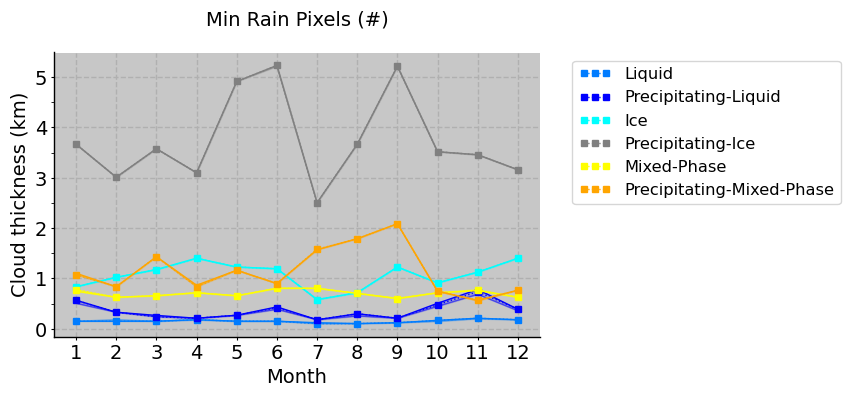

Liquid - Total cloud_lwp Variation between min_rainp (5, 15): 0.00
Precipitating-Liquid - Total cloud_lwp Variation between min_rainp (5, 15): 0.01
Mixed-Phase - Total cloud_lwp Variation between min_rainp (5, 15): 0.00
Precipitating-Mixed-Phase - Total cloud_lwp Variation between min_rainp (5, 15): 0.00


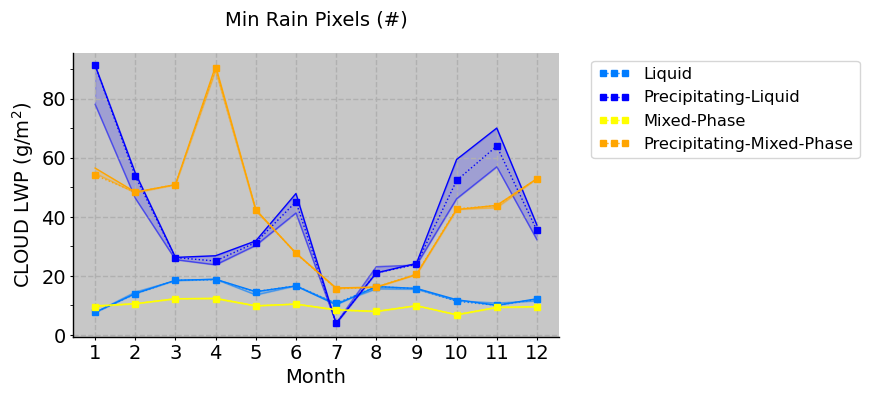

Ice - Total cloud_iwp Variation between min_rainp (5, 15): -0.00
Precipitating-Ice - Total cloud_iwp Variation between min_rainp (5, 15): 0.00
Mixed-Phase - Total cloud_iwp Variation between min_rainp (5, 15): -0.00
Precipitating-Mixed-Phase - Total cloud_iwp Variation between min_rainp (5, 15): 0.00


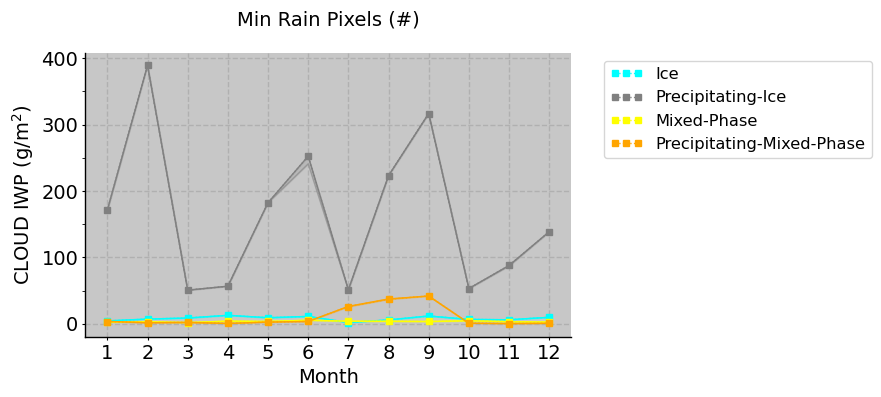

In [4]:
plt.close('all')
dic_cloud_colors = {"Liquid": "#007CFF", 
                     "Precipitating-Liquid": "blue", 
                     "Ice": "cyan", 
                     "Precipitating-Ice": "grey", 
                     "Mixed-Phase": "yellow", 
                     "Precipitating-Mixed-Phase": "orange"}

pattern_list = [
                "*min_cloudp.nc",
                "*min_liquid_percentage.nc",
                "*min_ice_percentage.nc",
                "*min_rainp.nc",
                ]

for pattern in pattern_list:
    filenames_occurence  = glob.glob(os.path.join(filepath_cloud_occurence, pattern))
    filenames_cloud_type = glob.glob(os.path.join(filepath_cloud_cloud_type, pattern))
    filenames_properties = glob.glob(os.path.join(filepath_data, pattern))
    key = pattern[1:-3]

    # This will combine all files along the 'time' dimension by default
    ds_occ  = xr.open_mfdataset(filenames_occurence, combine='by_coords').compute()
    ds_ctp = xr.open_mfdataset(filenames_cloud_type, combine='by_coords').compute()
    ds_prop = xr.open_mfdataset(filenames_properties, combine='by_coords').compute()

    # For LWP and  IWP, fill 0 with NaN in ds_prop to avoid medians around zero to be biased by the large number of zero values (clear sky or very thin clouds)
    if 'cloud_lwp' in ds_prop.data_vars:
        ds_prop['cloud_lwp'] = ds_prop['cloud_lwp'].where(ds_prop['cloud_lwp'] > 0)
    if 'cloud_iwp' in ds_prop.data_vars:
        ds_prop['cloud_iwp'] = ds_prop['cloud_iwp'].where(ds_prop['cloud_iwp'] > 0)
    
    clouds = list(ds_ctp.data_vars)[:-1]
    parameter_names = {'min_liquid_percentage': 'Min Liquid Percentage (%)',
                    'min_ice_percentage': 'Min Ice Percentage (%)',
                    'min_cloudp': 'Min Number of Cloud Pixels (#)',
                    'min_rainp': 'Min Rain Pixels (#)'
                    }

    coordinates_to_remove = {'min_cloudp':[0, 20, 40, 160],
                        'min_liquid_percentage':[50, 55, 95, 100],
                        'min_ice_percentage': [60, 65, 70, 75],
                        'min_rainp':[0, 20],
                        }

    standard_cba_thre = {'min_cloudp':100,
                        'min_liquid_percentage':70,
                        'min_ice_percentage':90,
                        'min_rainp':10,
                        }
    # ----------------------------------------------------------------------------------------------------------------
    # First plot the occurrences
    # ----------------------------------------------------------------------------------------------------------------
    if coordinates_to_remove[key] is not None:
        for i, value in enumerate(coordinates_to_remove[key]):
            if i == 0:
                mask_coord = (ds_prop[key] != value)
            else:
                mask_coord &= (ds_prop[key] != value)

        ds_occ = ds_occ.where(mask_coord, drop=True)
        ds_ctp = ds_ctp.where(mask_coord, drop=True)
        ds_prop = ds_prop.where(mask_coord, drop=True)

    mask_single_layer = (ds_occ.single_layer == 1)
    mask_attenuation = (ds_occ.attenuation == False)
    mask = mask_single_layer & mask_attenuation

    prop    = list(ds_prop.data_vars)
    thres_v = ( ds_prop[key].min(), ds_prop[key].max() )

    fig, ax = plt.subplots(figsize=(6,4))
    for cloud in clouds:
        # ds_prop = ds_prop.where(mask_cloud & mask)
        freq_occ = ds_ctp[cloud].where(mask, 0).groupby('time.month').mean()*100

        # take the mean by month
        # min_freq = freq_occ.min(dim=key)
        # max_freq = freq_occ.max(dim=key)
        
        min_freq = freq_occ.sel(**{key:thres_v[0]})
        max_freq = freq_occ.sel(**{key:thres_v[1]})
        
        min_freq_tot = ds_ctp[cloud].where(mask, 0).sel(**{key:thres_v[1]}).mean()*100
        max_freq_tot = ds_ctp[cloud].where(mask, 0).sel(**{key:thres_v[0]}).mean()*100
        diff_freq_tot = max_freq_tot - min_freq_tot
        print(f'{cloud} - Total occurrence Variation between {key} ({thres_v[0].item()}, {thres_v[1].item()}): {diff_freq_tot:.2f}%')
        
        standard_value = standard_cba_thre[key]

        # for each cloud, plot the standar value line and error bars between lower and upper freq
        ax.plot(freq_occ.month,
                freq_occ.sel(**{key:standard_value}), 
                linestyle=':',
                marker='s',
                markersize=4,
                color = dic_cloud_colors[cloud],
                label=f'{cloud}',
                )
        
        # plot the min and max freq to contextualize the variation
        # include a legend that explains the min and max lines
        ax.plot(min_freq.month, min_freq, linestyle='-', color = dic_cloud_colors[cloud], alpha=0.5)
        ax.plot(max_freq.month, max_freq, linestyle='-', color = dic_cloud_colors[cloud])

        ax.fill_between(freq_occ.month,
                        min_freq,
                        max_freq,
                        alpha=0.2,
                        color = dic_cloud_colors[cloud],
                        )
        
    ax.set_title(f'{parameter_names[key]}')
    ax.set_xlabel('Month')
    ax.set_xticks(np.arange(1,13,1)) # add ticks in x-axis at each month
    ax.yaxis.set_minor_locator(AutoMinorLocator(2)) # add subticks in y-axis at 0.5 intervals
    ax.set_ylabel('Cloud Occurrence (%)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small') # let the legend outside the plot on right side
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.savefig(os.path.join(figure_path, f'cloud_occurrence_{key}_sensitivity_analysis.png'), dpi=300, bbox_inches='tight')
    with open(os.path.join(figure_path, f'cloud_occurrence_{key}_sensitivity_analysis.pkl'), 'wb') as f:
        pickle.dump(fig, f)
    plt.show()

    # ----------------------------------------------------------------------------------------------------------------
    # Now plot the properties
    # ----------------------------------------------------------------------------------------------------------------

    for i, p in enumerate(prop):
        fig, ax = plt.subplots(figsize=(6,4))
        for cloud in clouds:

            if p == "cloud_lwp" and cloud in ["Ice", "Precipitating-Ice"]:
                continue
            if p == "cloud_iwp" and cloud in ["Liquid", "Precipitating-Liquid"]:
                continue

            mask_cloud = (ds_ctp[cloud] == 1.)
            # ds_prop = ds_prop.where(mask_cloud & mask)
            stat_ref = ds_prop[p].where(mask & mask_cloud).sel(**{key:standard_cba_thre[key]}).groupby('time.month').median()
            stat_lower = ds_prop[p].where(mask & mask_cloud).sel(**{key:thres_v[0]}).groupby('time.month').median()
            stat_upper = ds_prop[p].where(mask & mask_cloud).sel(**{key:thres_v[1]}).groupby('time.month').median()
           
            stat_min_tot = ds_prop[p].where(mask & mask_cloud).sel(**{key:thres_v[0]}).median()
            stat_max_tot = ds_prop[p].where(mask & mask_cloud).sel(**{key:thres_v[1]}).median()
            diff_tot = stat_max_tot - stat_min_tot
            print(f'{cloud} - Total {p} Variation between {key} ({thres_v[0].item()}, {thres_v[1].item()}): {diff_tot:.2f}')

            if p == 'cloud_lwp' or p == 'cloud_iwp':
                stat_ref = stat_ref*1000
                stat_lower = stat_lower*1000
                stat_upper = stat_upper*1000
                # let all CAPITAL
                ax.set_ylabel(p.replace('_', ' ').upper() + r' (g/m$^2$)')
            else:
                stat_ref = stat_ref/1000
                stat_lower = stat_lower/1000
                stat_upper = stat_upper/1000
                ax.set_ylabel(p.replace('_', ' ').capitalize() + ' (km)')
            
            ax.plot(stat_ref.month,
                    stat_ref,
                    linestyle=':',
                    marker='s',
                    markersize=4,
                    color = dic_cloud_colors[cloud],
                    label=f'{cloud}',
                    )
            
            # plot the min and max freq to contextualize the variation
            ax.plot(stat_lower.month, stat_lower, linestyle='-', color = dic_cloud_colors[cloud], alpha=0.5)
            ax.plot(stat_upper.month, stat_upper, linestyle='-', color = dic_cloud_colors[cloud])

            ax.fill_between(stat_ref.month,
                            stat_lower,
                            stat_upper,
                            alpha=0.2,
                            color = dic_cloud_colors[cloud],
                            )
            
        ax.set_title(f'{parameter_names[key]}')
        ax.set_xlabel('Month')
        ax.set_xticks(np.arange(1,13,1))
        # if i == 0:
        #     ax.legend( bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        # else:
        #     ax.legend().set_visible(False)
        ax.legend( bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        
        fig.savefig(os.path.join(figure_path, f'cloud_properties_{p}_{key}_sensitivity_analysis.png'), dpi=300, bbox_inches='tight')
        # save figure as pickle:
        with open(os.path.join(figure_path, f'cloud_properties_{p}_{key}_sensitivity_analysis.pkl'), 'wb') as f:
            pickle.dump(fig, f)
        plt.show()

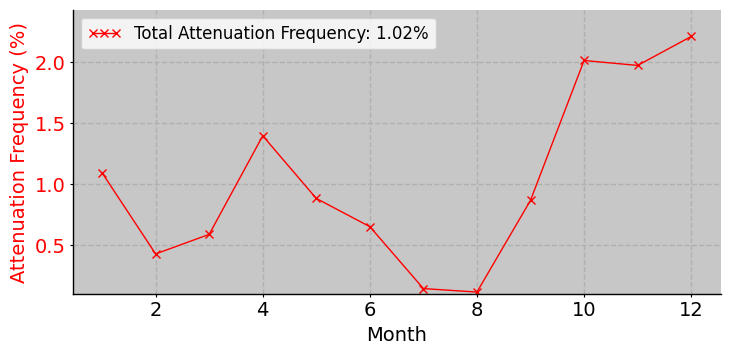

In [ ]:
freq_att = (~mask_attenuation).sel(**{key:standard_cba_thre[key]}).groupby('time.month').mean()*100
freq_tot = (~mask_attenuation).sel(**{key:standard_cba_thre[key]}).mean()*100

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(freq_att.month, freq_att, color='red', marker='x', linestyle='-', label=f"Total Attenuation Frequency: {freq_tot.values:.2f}%")
ax.legend(loc='upper left')
ax.set_xlabel('Month')
ax.set_ylabel('Attenuation Frequency (%)', color='red')
ax.tick_params(axis='y', labelcolor='red')
ax.set_ylim(freq_att.min()*0.9, freq_att.max()*1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.savefig(os.path.join(figure_path, f'attenuation_frequency_{key}_sensitivity_analysis.png'), dpi=500, bbox_inches='tight')
plt.show()

# Comparison between CBA and PBA: over-uniformity

### Reading PBA outputs

In [4]:
def clean_values(x):
    if x is None:
        return np.nan
    if isinstance(x, list):
        return np.nan
    return x

# -----------------------------------------------------------------------
# Old Method of cloud classification 
# -----------------------------------------------------------------------
# " DASK: >=2022.7.1,<2023.0.0"
root_folder = '/home/matheustolen/Documentos/matheus_doctorado/profile-based-processing/'
target_parent_folder = "number_of_layers"
# chirp_lwp = reading_dataset_chunking(root_folder, target_parent_folder)
print("Reading the netCDF files into a list of xarray datasets of old method...")
chirp_layers = reading_dataset_chunking(root_folder, target_parent_folder)

layer_list   = [ds for ds in chirp_layers.values()]
cloud_layers = xr.concat(layer_list, dim='time').sortby('time')

df_layers     = cloud_layers.to_dataframe()
mask_single   = (df_layers.sum(axis=1) == 1.0).to_numpy() # Mask with single layer for any kind of cloud
mask_multi    = (df_layers.sum(axis=1) > 1.0) # Mask with multi layer clouds
mask_w_clouds = (df_layers.sum(axis=1) == 0.0) # Mask with no clouds
del df_layers
#-------------------------------------------------------------------------------------------------
# NOTE: New variable is a mask, keep this sequence to avoid integer greater thabn 1
#-------------------------------------------------------------------------------------------------
ds_occ_pba = cloud_layers.where(mask_single, other=0.0)
ds_occ_pba['no_clouds']  = xr.DataArray(mask_w_clouds.astype(np.float64), dims='time')
ds_occ_pba['multilayer'] = xr.DataArray(mask_multi.astype(np.float64), dims='time')
# fill nan values with 0
ds_occ_pba = ds_occ_pba.fillna(0.0) # fill no single layer clouds by zero values
# ds_occ_pba = ds_occ_pba.assign_coords(years=ds_occ_pba['time'].dt.year,
#                                                             month=ds_occ_pba['time'].dt.month
#                                                             ).compute()
# print("End of reading the netCDF files into a list of xarray datasets...")

if 'Pre_liquid' in ds_occ_pba.data_vars:
    ds_occ_pba = ds_occ_pba.rename({'Pre_liquid': 'Precipitating-Liquid',
                                                        'Mixed_phase': 'Mixed-Phase',
                                                        'Pre_mixed_phase': 'Precipitating-Mixed-Phase'})
    ds_occ_pba_single_layer = ds_occ_pba.drop_vars(['no_clouds', 'multilayer']).compute()

Reading the netCDF files into a list of xarray datasets of old method...


In [5]:

target_parent_folder = "cloud_physical_properties"
# chirp_lwp = reading_dataset_chunking(root_folder, target_parent_folder)
chirp_cloud_prop = reading_dataset_chunking(root_folder, target_parent_folder)
# Remove IWP and LWP variables from chirp_cloud_prop for each dictionary key
chirp_integrated_var_list = []
dropped_vars = ['IWP', 'LWP']
for key, value in chirp_cloud_prop.items():
    chirp_integrated_var_list.append(value[dropped_vars])

# Concatenate the modified chirp_cloud_prop datasets
ds_intvar_pba_single_layer              = xr.concat(chirp_integrated_var_list, dim='time').sortby('time')
ds_intvar_pba_single_layer = ds_intvar_pba_single_layer.where(mask_single).compute() # Select integrated variables only for single layer clouds

In [6]:
target_parent_folder = "height_cloud_base"
file_extension = '.json'
chirp_height_cb = reading_dataset_chunking(root_folder, target_parent_folder, file_extension=file_extension)
target_parent_folder = "height_cloud_top"
file_extension = '.json'
chirp_height_ct = reading_dataset_chunking(root_folder, target_parent_folder, file_extension=file_extension)
target_parent_folder = "geometric_cloud_thickness"
file_extension = '.json'
chirp_height_cg = reading_dataset_chunking(root_folder, target_parent_folder, file_extension=file_extension)

freq_str = "M"

chirp_height_cb_list = [ds for ds in chirp_height_cb.values()]
cloud_prop_cb = xr.concat(chirp_height_cb_list, dim='time').sortby('time')

chirp_height_ct_list = [ds for ds in chirp_height_ct.values()]
cloud_prop_ct = xr.concat(chirp_height_ct_list, dim='time').sortby('time')

chirp_height_cg_list = [ds for ds in chirp_height_cg.values()]
cloud_prop_cg = xr.concat(chirp_height_cg_list, dim='time').sortby('time')

cloud_base_single      = cloud_prop_cb.where(mask_single).compute() # Select only single layer clouds
cloud_top_single       = cloud_prop_ct.where(mask_single).compute() # Select only single layer clouds
cloud_thickness_single = cloud_prop_cg.where(mask_single).compute() # Select only single layer clouds

# if 'Pre_liquid' in cloud_base_single .data_vars:
#     cloud_base_single  = cloud_base_single .rename({'Pre_liquid': 'Precipitating-Liquid',
#                                                         'Mixed_phase': 'Mixed-Phase',
#                                                         'Pre_mixed_phase': 'Precipitating-Mixed-Phase'})
#     cloud_top_single  = cloud_top_single .rename({'Pre_liquid': 'Precipitating-Liquid',
#                                                     'Mixed_phase': 'Mixed-Phase',
#                                                     'Pre_mixed_phase': 'Precipitating-Mixed-Phase'})
#     cloud_thickness_single  = cloud_thickness_single .rename({'Pre_liquid': 'Precipitating-Liquid',
#                                                         'Mixed_phase': 'Mixed-Phase',
#                                                         'Pre_mixed_phase': 'Precipitating-Mixed-Phase'})

cloud_base_single = cloud_base_single.map(lambda da: xr.apply_ufunc(
    np.vectorize(clean_values, otypes=[float]),
    da,
    dask="allowed"
))

cloud_top_single = cloud_top_single.map(lambda da: xr.apply_ufunc(
    np.vectorize(clean_values, otypes=[float]),
    da,
    dask="allowed"
))

cloud_thickness_single = cloud_thickness_single.map(lambda da: xr.apply_ufunc(
    np.vectorize(clean_values, otypes=[float]),
    da,
    dask="allowed"
))

# create an xarray dataset with the three variables with time as coordinate: cloud_base_single, cloud_top_single and cloud_thickness_single
ds_prop_pba_single_layer = xr.Dataset({ 
    'cloud_base':  cloud_base_single.to_array(dim="cloud_type").max(dim="cloud_type"),
    'cloud_thickness': cloud_thickness_single.to_array(dim="cloud_type").max(dim="cloud_type"),
    'cloud_iwp': ds_intvar_pba_single_layer['IWP'],
    'cloud_lwp': ds_intvar_pba_single_layer['LWP'],
    }, coords={'time': cloud_base_single.time})
    

### Reading CBA outputs

In [7]:
standard_cba_thre = {'min_cloudp':100,
                    'min_liquid_percentage':70,
                    'min_ice_percentage':90,
                    'min_rainp':10,
                    }

pattern = "*min_rainp.nc"
filenames_occurence  = glob.glob(os.path.join(filepath_cloud_occurence, pattern))
filenames_cloud_type = glob.glob(os.path.join(filepath_cloud_cloud_type, pattern))
filenames_properties = glob.glob(os.path.join(filepath_data, pattern))
filenames_duration = glob.glob(os.path.join(filepath_cloud_duration, "*.pkl"))

key = pattern[1:-3]
# This will combine all files along the 'time' dimension by default
ds_occ_cba = xr.open_mfdataset(filenames_occurence, combine='by_coords').sel(**{key: standard_cba_thre[key]}).compute()
ds_ctp_cba = xr.open_mfdataset(filenames_cloud_type, combine='by_coords').sel(**{key: standard_cba_thre[key]}).compute()
ds_prop = xr.open_mfdataset(filenames_properties, combine='by_coords').sel(**{key: standard_cba_thre[key]}).compute()

# read pkl files with duration of each cloud type for each day and concatenate them in a single dictionary
dic_duration = {}
for file in filenames_duration:
    with open(file, 'rb') as f:
        dic = pickle.load(f)
        for key in dic.keys():
            if key in dic_duration:
                dic_duration[key] += (dic[key])
            else:
                dic_duration[key] = dic[key]

In [22]:
ds_prop.head

<bound method Dataset.head of <xarray.Dataset>
Dimensions:          (time: 3976104)
Coordinates:
  * time             (time) datetime64[ns] 2018-04-23T15:28:45.001144409 ... ...
    min_rainp        int64 10
Data variables:
    cloud_base       (time) float64 4.474e+03 4.407e+03 ... 5.372e+03 5.372e+03
    cloud_thickness  (time) float64 1.298e+03 1.364e+03 ... 5.665e+03 5.665e+03
    cloud_lwp        (time) float64 0.0 0.0 0.0 ... 0.003444 0.003203 0.00104
    cloud_iwp        (time) float64 0.02524 0.01677 0.01001 ... 0.1925 0.1928>

In [8]:
mask = (ds_occ_cba.single_layer == 1 ) & (ds_occ_cba.attenuation == False)
ds_prop_cba_single_layer = ds_prop.where(mask)
ds_occ_cba_single_layer = ds_occ_cba.where(mask, 0)
ds_ctp_cba_single_layer = ds_ctp_cba.where(mask, 0)
ds_prop_cba_single_layer.head

<bound method Dataset.head of <xarray.Dataset>
Dimensions:          (time: 3976104)
Coordinates:
  * time             (time) datetime64[ns] 2018-04-23T15:28:45.001144409 ... ...
    min_rainp        int64 10
Data variables:
    cloud_base       (time) float64 4.474e+03 4.407e+03 ... 5.372e+03 5.372e+03
    cloud_thickness  (time) float64 1.298e+03 1.364e+03 ... 5.665e+03 5.665e+03
    cloud_lwp        (time) float64 0.0 0.0 0.0 ... 0.003444 0.003203 0.00104
    cloud_iwp        (time) float64 0.02524 0.01677 0.01001 ... 0.1925 0.1928>

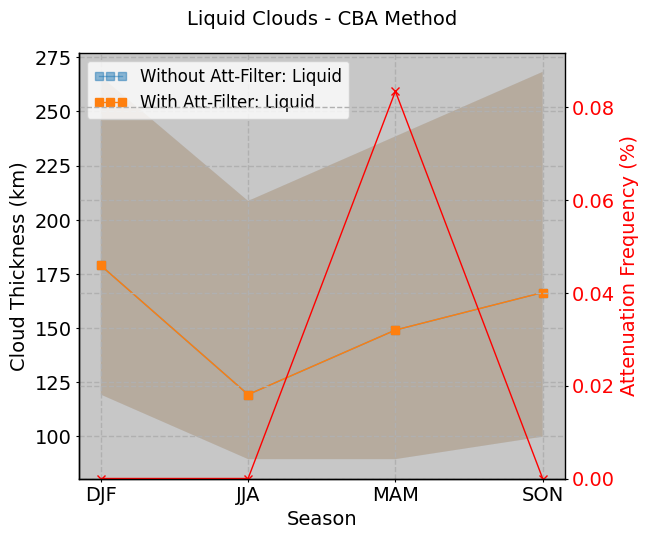

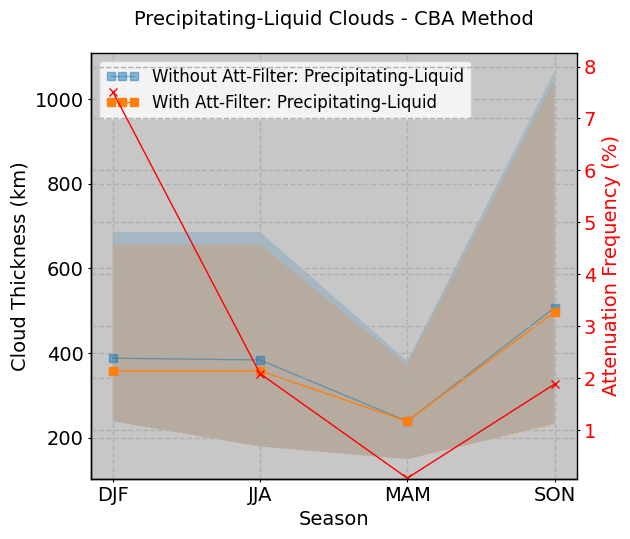

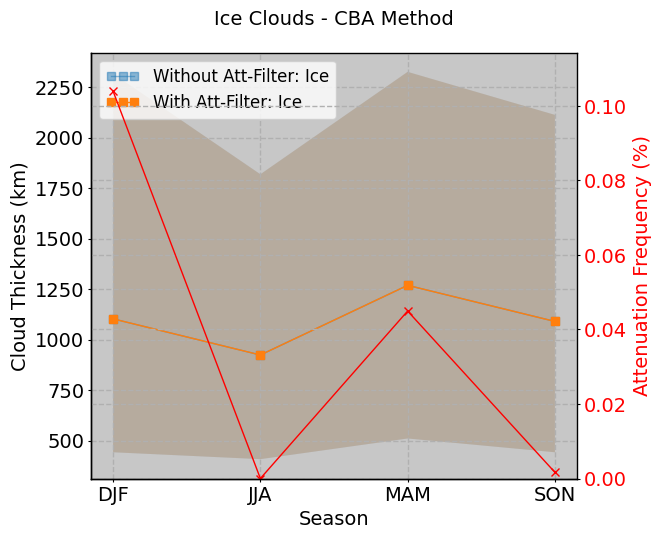

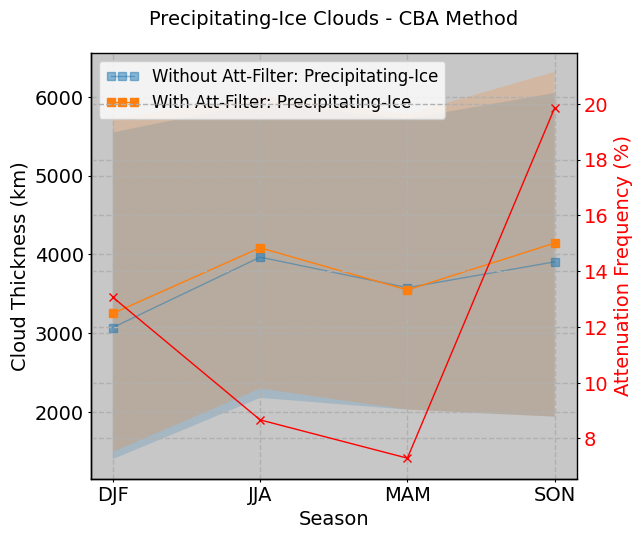

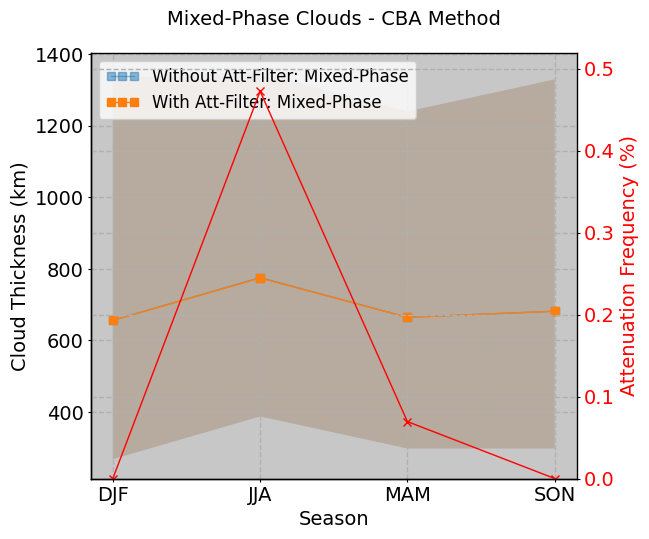

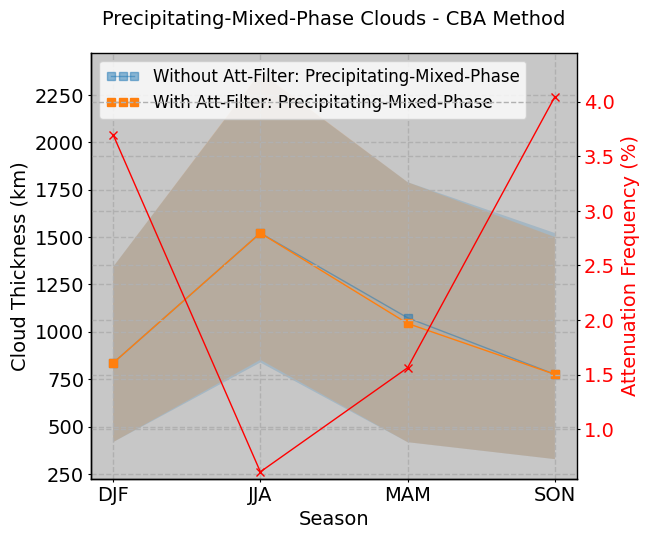

In [45]:
# Plot cloud thickness per season for each cloud type for CBA method
clouds = list(ds_ctp_cba_single_layer.data_vars)[:-1]
p = 'cloud_thickness'
for cloud in clouds:
    fig, ax = plt.subplots(figsize=(6,6))
    mask_single_la = (ds_occ_cba.single_layer == 1 )
    mask_att = (ds_occ_cba.attenuation == False)
    mask_cloud = (ds_ctp_cba[cloud] == 1.)
    ds_with_att = ds_prop[p].where(mask_single_la & mask_cloud).groupby('time.season').median()
    ds_wit_att_q25 = ds_prop[p].where(mask_single_la & mask_cloud).groupby('time.season').quantile(0.25)
    ds_wit_att_q75 = ds_prop[p].where(mask_single_la & mask_cloud).groupby('time.season').quantile(0.75)
    ds_without_att = ds_prop[p].where(mask_single_la & mask_att & mask_cloud).groupby('time.season').median()
    ds_without_att_q25 = ds_prop[p].where(mask_single_la & mask_att & mask_cloud).groupby('time.season').quantile(0.25)
    ds_without_att_q75 = ds_prop[p].where(mask_single_la & mask_att & mask_cloud).groupby('time.season').quantile(0.75)

    ax.plot(ds_with_att['season'], ds_with_att, label=f'Without Att-Filter: {cloud}', marker='s', linestyle='-', alpha=0.5)
    ax.fill_between(ds_with_att['season'],
                    ds_wit_att_q25,
                    ds_wit_att_q75,
                    alpha=0.2,
                    # color=dic_cloud_colors[cloud],
                    )
    ax.plot(ds_without_att['season'], ds_without_att, label=f'With Att-Filter: {cloud}', marker='s', linestyle='-')
    ax.fill_between(ds_without_att['season'],
                    ds_without_att_q25,
                    ds_without_att_q75,
                    alpha=0.2,
                    # color=dic_cloud_colors[cloud],
                    )
    # in the second y-axis, plot the frequency of attenuation for each season for the given cloud type
    freq_att_season = (~mask_att).where(mask_single_la & mask_cloud).groupby('time.season').mean()*100
    ax2 = ax.twinx()
    ax2.plot(freq_att_season['season'], freq_att_season, color='red', marker='x', linestyle='-', label=f'Attenuation Frequency: {cloud}')
    ax2.set_ylabel('Attenuation Frequency (%)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(freq_att_season.min()*0.9, freq_att_season.max()*1.1)
    
    ax.set_title(f'{cloud} Clouds - CBA Method')
    ax.set_xlabel('Season')
    ax.set_ylabel('Cloud Thickness (km)')
    ax.legend(loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # fig.savefig(os.path.join(figure_path, f'cloud_thickness_{cloud}_{key}_sensitivity_analysis.png'), dpi=300, bbox_inches='tight')
    with open(os.path.join(figure_path, f'att_filter_influence_{cloud}.pkl'), 'wb') as f:
        pickle.dump(fig, f)
    plt.show()

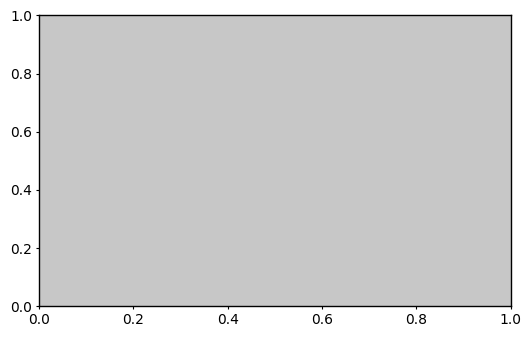

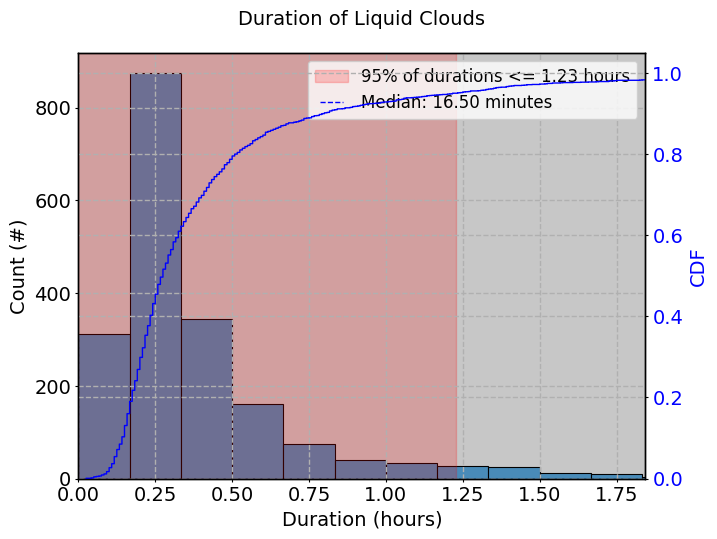

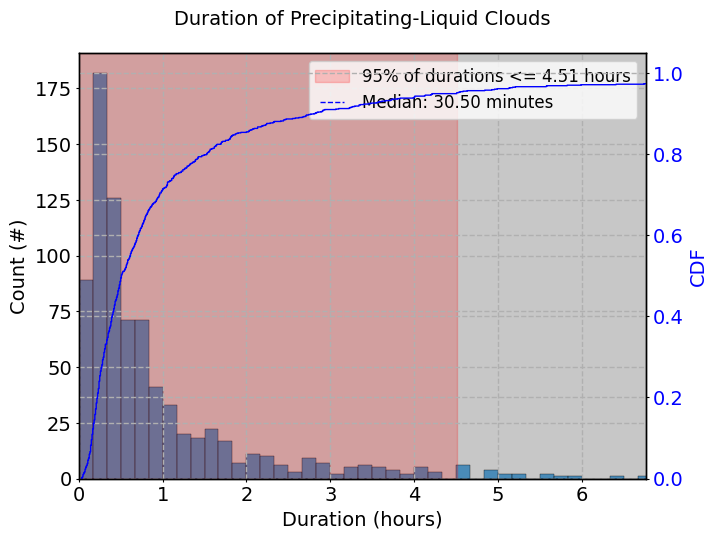

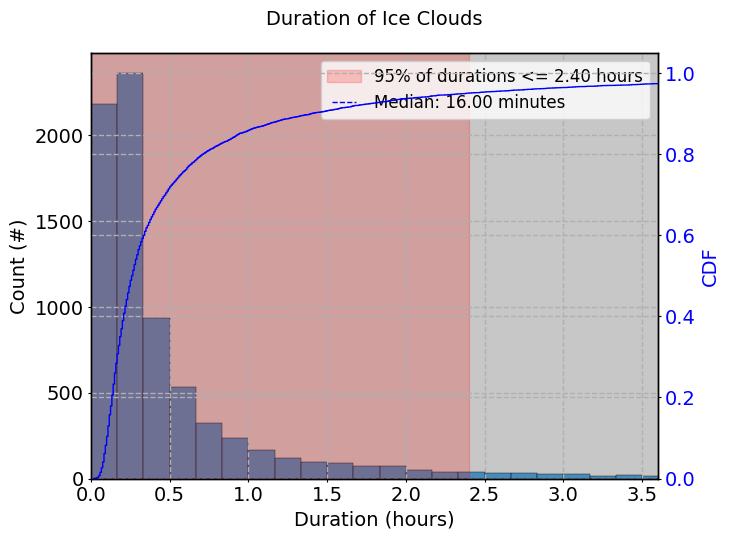

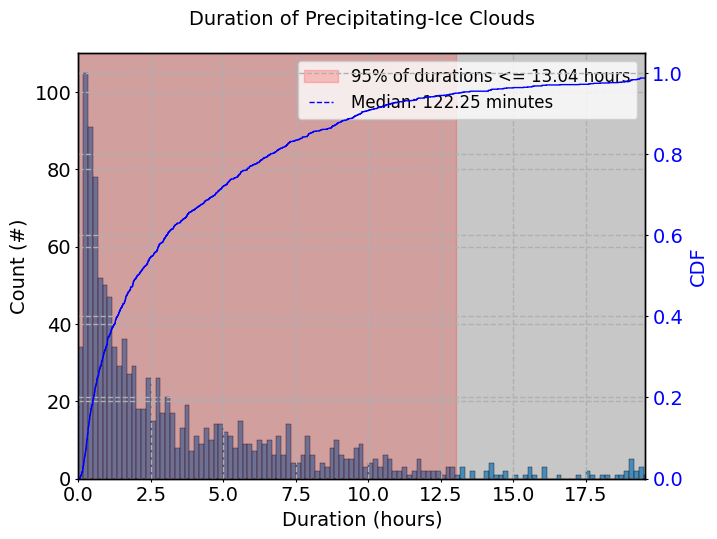

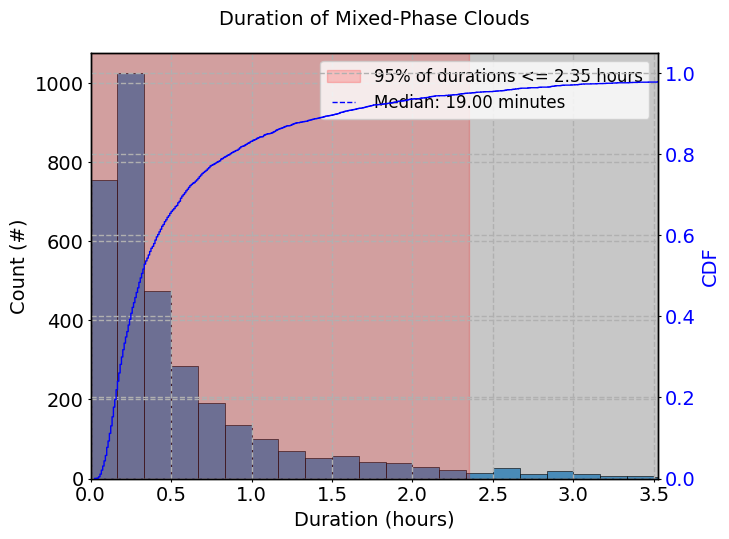

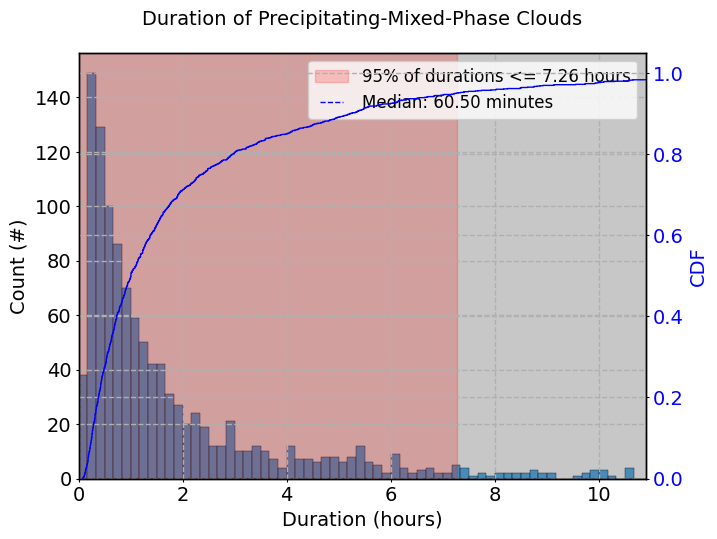

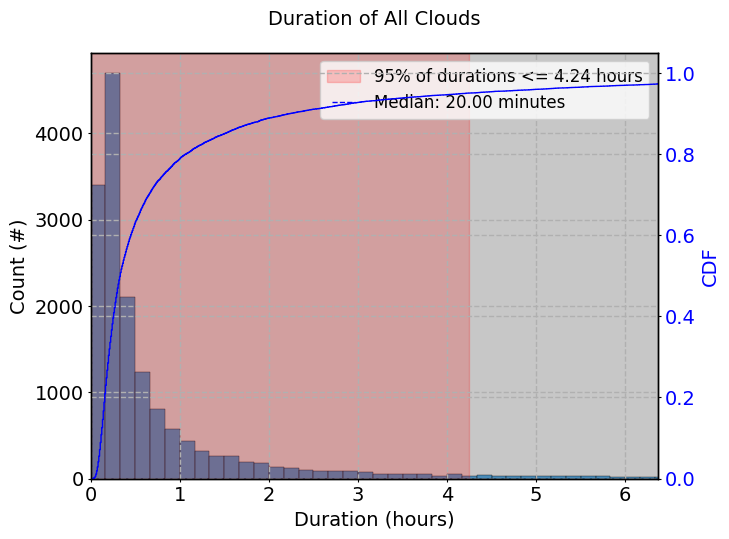

In [9]:
# For each cloud type, plot the histogram o of the duration with bin leght of 10 minutes, and the median duration as a vertical line in the histogram
plt.close('all')
for cloud_type in dic_duration:
    duration = dic_duration[cloud_type]
    duration = [d for d in duration if d is not None and not isinstance(d, list)]
    fig, ax = plt.subplots(figsize=(7,6))
    sns.histplot(duration, bins=np.arange(0, max(duration)+10/60, 10/60), kde=False)
    # fill the area with 95% confidence interval of the duration
    ci_upper = np.percentile(duration, 95)
    value_at_95 = np.percentile(duration, 95)
    ax.axvspan(0, ci_upper, color='red', alpha=0.2, label=f'95% of durations <= {value_at_95:.2f} hours')
    ax.set_xlim(0, ci_upper*1.5)
    median_duration = np.median(duration)*60 # convert to minutes
    ax.axvline(median_duration, color='blue', linestyle='--', label=f'Median: {median_duration:.2f} minutes')
    
    # show the CDF of the duration in the same plot with a secondary y-axis
    ax2 = ax.twinx()
    sns.ecdfplot(duration, ax=ax2, color='blue', label='CDF of durations')
    ax2.set_ylabel('CDF', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.set_ylim(0, 1.05)
    
    ax.set_title(f'Duration of {cloud_type} Clouds')
    ax.set_xlabel('Duration (hours)')
    ax.set_ylabel('Count (#)')
    ax.legend()
    ax.grid(True, which="both", ls="--")
    plt.show()

# 95 percentile of all durations of all cloud types together
all_durations = []
for cloud_type in dic_duration:
    duration = dic_duration[cloud_type]
    duration = [d for d in duration if d is not None and not isinstance(d, list)]
    all_durations += duration

fig, ax = plt.subplots(figsize=(7,6))
sns.histplot(all_durations, bins=np.arange(0, max(all_durations)+10/60, 10/60), kde=False)
# fill the area with 95% confidence interval of the duration
ci_upper = np.percentile(all_durations, 95)
value_at_95 = np.percentile(all_durations, 95)
ax.axvspan(0, ci_upper, color='red', alpha=0.2, label=f'95% of durations <= {value_at_95:.2f} hours')
ax.set_xlim(0, ci_upper*1.5)
median_duration = np.median(all_durations)*60 # convert to minutes
ax.axvline(median_duration, color='blue', linestyle='--', label=f'Median: {median_duration:.2f} minutes')
# show the CDF of the duration in the same plot with a secondary y-axis
ax2 = ax.twinx()
sns.ecdfplot(all_durations, ax=ax2, color='blue', label='CDF of durations')
ax2.set_ylabel('CDF', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0, 1.05)   
ax.set_title(f'Duration of All Clouds')
ax.set_xlabel('Duration (hours)')
ax.set_ylabel('Count (#)')
ax.legend()
ax.grid(True, which="both", ls="--")
plt.show()

In [64]:
time_to_resample = 'month'
group = False
if group:
    time_to_resample = 'month'
    new_time = ds_ctp_cba_single_layer["Ice"].groupby('time.' + time_to_resample).mean().month
else:
    time_to_resample = 'D'
    new_time = ds_ctp_cba_single_layer["Ice"].resample(time=time_to_resample).mean().time

vars  = [
        'Liquid',
        'Precipitating-Liquid',
        'Ice',
        'Mixed-Phase',
        'Precipitating-Mixed-Phase',
        ]

if group: 
    stats_cba = xr.Dataset(coords={"month": new_time}, data_vars={cloud: (("month"), np.full(len(new_time), np.nan)) for cloud in vars})
    stats_pba = xr.Dataset(coords={"month": new_time}, data_vars={cloud: (("month"), np.full(len(new_time), np.nan)) for cloud in vars})
else:
    stats_cba = xr.Dataset(coords={"time": new_time}, data_vars={cloud: (("time"), np.full(len(new_time), np.nan)) for cloud in vars})
    stats_pba = xr.Dataset(coords={"time": new_time}, data_vars={cloud: (("time"), np.full(len(new_time), np.nan)) for cloud in vars})


prop = "cloud_base"
for cloud in vars:
    # mask_pba = (ds_occ_pba_single_layer[cloud] == 1.) & (ds_ctp_cba["Not Classified"] == 0.) & (ds_occ_cba.attenuation == False)
    mask_pba = (ds_occ_pba_single_layer[cloud] == 1.)
    ds_ctp_cba_single_layer[cloud]
    if group:
        stats_cba[cloud] = ds_prop_cba_single_layer[prop].where(ds_ctp_cba_single_layer[cloud] == 1.).groupby('time.' + time_to_resample).mean()
        stats_pba[cloud] = ds_prop_pba_single_layer[prop].where(mask_pba).groupby('time.' + time_to_resample).mean()
    else:
        stats_cba[cloud] = ds_prop_cba_single_layer[prop].where(ds_ctp_cba_single_layer[cloud] == 1.).resample(time=time_to_resample).mean()
        stats_pba[cloud] = ds_prop_pba_single_layer[prop].where(mask_pba).resample(time=time_to_resample).mean()
   

In [65]:
# Compute the correlation each var in stats:
# first, trasnform to dataframe and pivot to have cloud types as columns and time as index, then compute the correlation matrix
if group:
    df_stats_cba = stats_cba.to_dataframe().reset_index().drop(columns=['month', 'min_rainp'])
else:
    df_stats_cba = stats_cba.to_dataframe().reset_index().drop(columns=['time', 'min_rainp'])
correlation_matrix_cba = df_stats_cba.corr()

correlation_matrix_cba.style.background_gradient(cmap='coolwarm').set_precision(2)

/tmp/ipykernel_269144/143744155.py:9: FutureWarning: this method is deprecated in favour of `Styler.format(precision=..)`
  correlation_matrix_cba.style.background_gradient(cmap='coolwarm').set_precision(2)


,Liquid,Precipitating-Liquid,Ice,Mixed-Phase,Precipitating-Mixed-Phase
Liquid,1.00,0.48,0.16,0.18,0.70
Precipitating-Liquid,0.48,1.00,0.06,0.10,0.46
Ice,0.16,0.06,1.00,0.56,0.05
Mixed-Phase,0.18,0.10,0.56,1.00,0.35
Precipitating-Mixed-Phase,0.70,0.46,0.05,0.35,1.00


In [66]:
if group:
    df_stats_pba = stats_pba.to_dataframe().reset_index().drop(columns=['month', 'min_rainp'])
else:
    df_stats_pba = stats_pba.to_dataframe().reset_index().drop(columns=['time', 'min_rainp'])
correlation_matrix_pba = df_stats_pba.corr()
correlation_matrix_pba.style.background_gradient(cmap='coolwarm').set_precision(2)

/tmp/ipykernel_269144/2903188772.py:6: FutureWarning: this method is deprecated in favour of `Styler.format(precision=..)`
  correlation_matrix_pba.style.background_gradient(cmap='coolwarm').set_precision(2)


,Liquid,Precipitating-Liquid,Ice,Mixed-Phase,Precipitating-Mixed-Phase
Liquid,1.00,0.50,0.53,0.67,0.24
Precipitating-Liquid,0.50,1.00,0.19,0.29,0.49
Ice,0.53,0.19,1.00,0.80,0.40
Mixed-Phase,0.67,0.29,0.80,1.00,0.33
Precipitating-Mixed-Phase,0.24,0.49,0.40,0.33,1.00


In [ ]:
# # ds = ds_ctp_cba.where(ds_occ_cba.single_layer == 1 )
# ds = ds_ctp_cba.copy()
# tol = np.timedelta64(32, "s")
# for cloud in ds.data_vars:
#     ds_cloud = ds[cloud].where(ds[cloud] == 1., drop=True)
#     time = ds_cloud.time
#     # print("time detected:", time[:20])
#     time_diff = time.diff('time').astype('timedelta64[s]')
#     mask_occurence = time_diff < tol
#     split_indices = np.where(~mask_occurence)[0] + 1
#     cloud_events = np.split(ds_cloud.values, split_indices)
#     # count the number of events and the duration of each event
#     event_durations = [len(event)*30/60/60 for event in cloud_events] # duration in seconds
#     # statistical summary of the event durations
#     max_duration = np.max(event_durations)

#     fig, ax = plt.subplots(figsize=(6,5))
#     sns.histplot(event_durations, bins=70, kde=False, ax=ax, label='Max Duration: {:.2f} hours'.format(max_duration))
#     ax.set_xlabel('Cloud Event Duration (hours)')
#     ax.set_title(f'Cloud Event Duration Distribution for {cloud} Clouds')
#     ax.legend()
#     # in the other axis, plot the cumulative distribution function (CDF) of the event durations
#     ax2 = ax.twinx()
#     sns.ecdfplot(event_durations, ax=ax2, color='red')
#     ax2.set_ylabel('CDF', color='red')
#     ax2.tick_params(axis='y', labelcolor='red')
#     # draw the are of CDF with 90% confidence interval
#     ax2.fill_betweenx([0, 1], 0, np.percentile(event_durations, 95), color='red', alpha=0.2)
    
#     #select x-axis limits according to the 99th percentile of the event durations
#     ax.set_xlim(0, np.percentile(event_durations, 97))
#     plt.show()


In [ ]:
props = list(ds_prop_cba_single_layer.data_vars)
cloud = 'Mixed-Phase'
for p in props:
    # plot a comparison between PBA and CBA methods for each property p
    ds_stat_cba = ds_prop_cba_single_layer.where(ds_ctp_cba[cloud])[p].resample(time='M').median()
    ds_stat_cba_q25 = ds_prop_cba_single_layer.where(ds_ctp_cba[cloud])[p].resample(time='M').quantile(0.25)
    ds_stat_cba_q75 = ds_prop_cba_single_layer.where(ds_ctp_cba[cloud])[p].resample(time='M').quantile(0.75)
    ds_stat_pba = ds_prop_pba_single_layer.where(ds_occ_pba_single_layer[cloud])[p].resample(time='M').median()
    ds_stat_pba_q25 = ds_prop_pba_single_layer.where(ds_occ_pba_single_layer[cloud])[p].resample(time='M').quantile(0.25)
    ds_stat_pba_q75 = ds_prop_pba_single_layer.where(ds_occ_pba_single_layer[cloud])[p].resample(time='M').quantile(0.75)

    fig, ax = plt.subplots(figsize=(10,5))

    if p == 'cloud_lwp' or p == 'cloud_iwp':
        ds_stat_cba = ds_stat_cba*1000
        ds_stat_cba_q25 = ds_stat_cba_q25*1000
        ds_stat_cba_q75 = ds_stat_cba_q75*1000
        ds_stat_pba = ds_stat_pba*1000
        ds_stat_pba_q25 = ds_stat_pba_q25*1000
        ds_stat_pba_q75 = ds_stat_pba_q75*1000
        ax.set_ylabel(p.replace('_', ' ').upper() + r' (g/m$^2$)')
    else:
        ds_stat_cba = ds_stat_cba/1000
        ds_stat_cba_q25 = ds_stat_cba_q25/1000
        ds_stat_cba_q75 = ds_stat_cba_q75/1000
        ds_stat_pba = ds_stat_pba/1000
        ds_stat_pba_q25 = ds_stat_pba_q25/1000
        ds_stat_pba_q75 = ds_stat_pba_q75/1000
        ax.set_ylabel(p.replace('_', ' ').capitalize() + ' (km)')
    
    ax.plot(ds_stat_cba['time'], ds_stat_cba, label='CBA Method', color='blue', marker='s', linestyle='-')
    ax.fill_between(ds_stat_cba['time'],
                    ds_stat_cba_q25,
                    ds_stat_cba_q75,
                    color='blue', alpha=0.2)
    ax.plot(ds_stat_pba['time'], ds_stat_pba, label='PBA Method', color='orange', marker='o', linestyle='--')
    ax.fill_between(ds_stat_pba['time'],
                    ds_stat_pba_q25,
                    ds_stat_pba_q75,
                    color='orange', alpha=0.2)  

    ax.set_title(f'Comparison of Cloud Property: {p.replace("_", " ").capitalize()} for {cloud} Clouds')
    ax.set_xlabel('Time')

    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.savefig(os.path.join(figure_path, f'comparison_{p}_{cloud}_CBA_PBA.png'), dpi=300, bbox_inches='tight')
    plt.show()


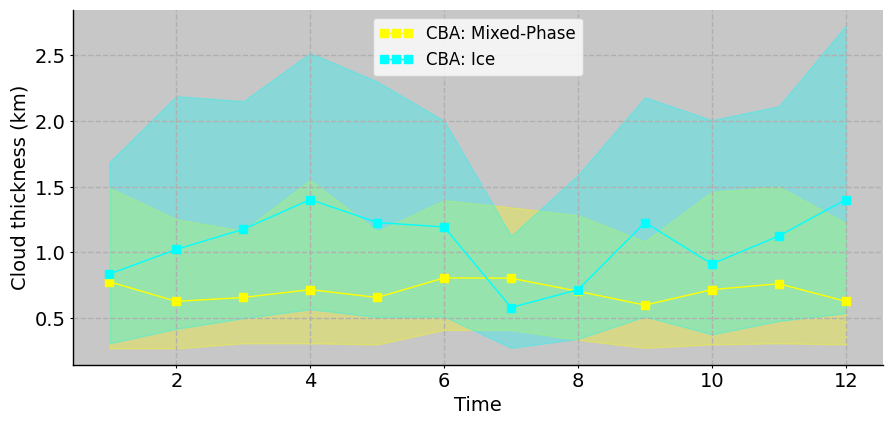

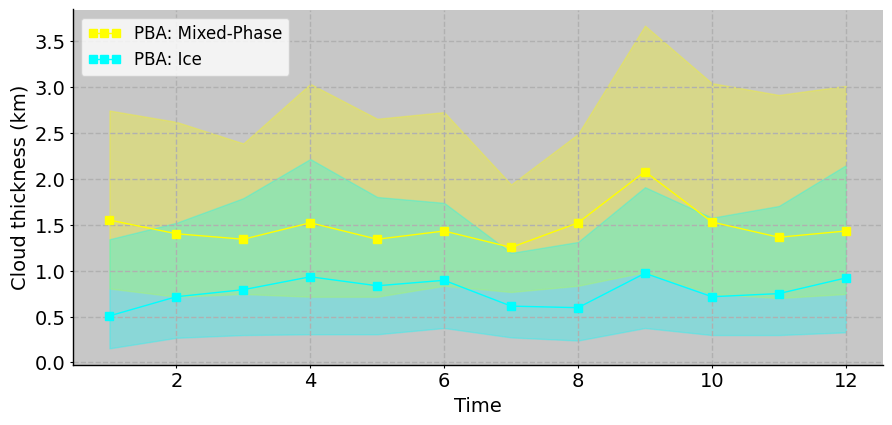

In [13]:
dic_cloud_colors = {"Liquid": "#007CFF", 
                     "Precipitating-Liquid": "blue", 
                     "Ice": "cyan", 
                     "Precipitating-Ice": "grey", 
                     "Mixed-Phase": "yellow", 
                     "Precipitating-Mixed-Phase": "orange"}

props_all = list(ds_prop_cba_single_layer.data_vars)
clouds = ['Mixed-Phase', 'Ice']
p      = 'cloud_thickness'

dic_method = {'CBA': ds_prop_cba_single_layer,
              'PBA': ds_prop_pba_single_layer}
dic_cloud_type = {'CBA':ds_ctp_cba,
                  'PBA':ds_occ_pba}

for met in dic_method.keys():
    fig, ax = plt.subplots(figsize=(10,5))
    for cloud in clouds:
        # plot a comparison between PBA and CBA methods for each property p
        ds_stat = dic_method[met].where(dic_cloud_type[met][cloud])[p].compute().groupby('time.month').median()
        ds_stat_q25 = dic_method[met].where(dic_cloud_type[met][cloud])[p].compute().groupby('time.month').quantile(0.25)
        ds_stat_q75 = dic_method[met].where(dic_cloud_type[met][cloud])[p].compute().groupby('time.month').quantile(0.75)

        if p == 'cloud_lwp' or p == 'cloud_iwp':
            ds_stat = ds_stat*1000
            ds_stat_q25 = ds_stat_q25*1000
            ds_stat_q75 = ds_stat_q75*1000
            ax.set_ylabel(p.replace('_', ' ').upper() + r' (g/m$^2$)')
        else:
            ds_stat = ds_stat/1000
            ds_stat_q25 = ds_stat_q25/1000
            ds_stat_q75 = ds_stat_q75/1000
            ax.set_ylabel(p.replace('_', ' ').capitalize() + ' (km)')
        
        ax.plot(ds_stat['month'], ds_stat, label=f'{met}: {cloud}', marker='s', linestyle='-', color=dic_cloud_colors[cloud])
        ax.fill_between(ds_stat['month'],
                        ds_stat_q25,
                        ds_stat_q75, 
                        alpha=0.3,
                        color=dic_cloud_colors[cloud],
                        )

    # ax.set_title(f'Comparison of Cloud Property: {p.replace("_", " ").capitalize()} for {cloud} Clouds')
    ax.set_xlabel('Time')

    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # fig.savefig(os.path.join(figure_path, f'comparison_{p}_{cloud}_CBA_PBA.png'), dpi=300, bbox_inches='tight')
    with open(os.path.join(figure_path, f'comparison_mixed_ice_{met}.pkl'), 'wb') as f:
        pickle.dump(fig, f)
    plt.show()


In [ ]:
cba_cloud_thickness = ds_prop_cba_single_layer.where(ds_ctp_cba['Mixed-Phase'])['cloud_thickness'].resample(time='D').median()
pba_cloud_thickness = ds_prop.where(ds_occ_pba['Mixed-Phase'])['cloud_thickness'].resample(time='D').median()

diff_methods_thickness = cba_cloud_thickness - pba_cloud_thickness
mask_large_diff = np.abs(diff_methods_thickness) > 1000  # 1 km threshold

In [ ]:
diff_methods_thickness[mask_large_diff].time

<xarray.DataArray 'time' (time: 188)>
array(['2018-07-19T00:00:00.000000000', '2018-08-16T00:00:00.000000000',
       '2018-08-27T00:00:00.000000000', '2018-08-30T00:00:00.000000000',
       '2018-09-11T00:00:00.000000000', '2018-09-14T00:00:00.000000000',
       '2018-09-26T00:00:00.000000000', '2018-10-01T00:00:00.000000000',
       '2018-10-09T00:00:00.000000000', '2018-10-21T00:00:00.000000000',
       '2019-05-02T00:00:00.000000000', '2019-05-18T00:00:00.000000000',
       '2019-05-19T00:00:00.000000000', '2019-05-21T00:00:00.000000000',
       '2019-05-24T00:00:00.000000000', '2019-06-03T00:00:00.000000000',
       '2019-06-05T00:00:00.000000000', '2019-06-14T00:00:00.000000000',
       '2019-06-27T00:00:00.000000000', '2019-09-13T00:00:00.000000000',
       '2019-09-17T00:00:00.000000000', '2019-09-19T00:00:00.000000000',
       '2019-09-20T00:00:00.000000000', '2019-09-21T00:00:00.000000000',
       '2019-09-30T00:00:00.000000000', '2019-10-19T00:00:00.000000000',
       '2019-10-22T00:00:00.000000000', '2019-10-30T00:00:00.000000000',
       '2019-11-10T00:00:00.000000000', '2019-12-16T00:00:00.000000000',
       '2019-12-17T00:00:00.000000000', '2019-12-19T00:00:00.000000000',
       '2019-12-26T00:00:00.000000000', '2019-12-27T00:00:00.000000000',
       '2020-01-03T00:00:00.000000000', '2020-01-13T00:00:00.000000000',
       '2020-01-14T00:00:00.000000000', '2020-01-15T00:00:00.000000000',
       '2020-01-17T00:00:00.000000000', '2020-01-18T00:00:00.000000000',
       '2020-01-24T00:00:00.000000000', '2020-01-30T00:00:00.000000000',
       '2020-02-07T00:00:00.000000000', '2020-02-28T00:00:00.000000000',
       '2020-03-13T00:00:00.000000000', '2020-03-14T00:00:00.000000000',
       '2020-03-21T00:00:00.000000000', '2020-04-05T00:00:00.000000000',
       '2020-04-12T00:00:00.000000000', '2020-04-21T00:00:00.000000000',
       '2020-04-27T00:00:00.000000000', '2020-04-28T00:00:00.000000000',
       '2020-05-02T00:00:00.000000000', '2020-05-07T00:00:00.000000000',
       '2020-05-08T00:00:00.000000000', '2020-05-11T00:00:00.000000000',
       '2020-05-16T00:00:00.000000000', '2020-05-31T00:00:00.000000000',
       '2020-06-14T00:00:00.000000000', '2020-07-21T00:00:00.000000000',
       '2020-08-01T00:00:00.000000000', '2020-09-01T00:00:00.000000000',
       '2020-09-13T00:00:00.000000000', '2020-09-14T00:00:00.000000000',
       '2020-09-16T00:00:00.000000000', '2020-09-18T00:00:00.000000000',
       '2020-09-20T00:00:00.000000000', '2020-09-21T00:00:00.000000000',
       '2020-09-23T00:00:00.000000000', '2020-10-02T00:00:00.000000000',
       '2020-10-09T00:00:00.000000000', '2020-10-22T00:00:00.000000000',
       '2020-11-05T00:00:00.000000000', '2020-11-06T00:00:00.000000000',
       '2020-12-01T00:00:00.000000000', '2020-12-14T00:00:00.000000000',
       '2020-12-16T00:00:00.000000000', '2020-12-25T00:00:00.000000000',
       '2021-01-10T00:00:00.000000000', '2021-02-05T00:00:00.000000000',
       '2021-02-25T00:00:00.000000000', '2021-03-01T00:00:00.000000000',
       '2021-03-07T00:00:00.000000000', '2021-03-19T00:00:00.000000000',
       '2021-03-26T00:00:00.000000000', '2021-03-29T00:00:00.000000000',
       '2021-04-04T00:00:00.000000000', '2021-04-08T00:00:00.000000000',
       '2021-04-09T00:00:00.000000000', '2021-04-13T00:00:00.000000000',
       '2021-04-16T00:00:00.000000000', '2021-04-21T00:00:00.000000000',
       '2021-04-26T00:00:00.000000000', '2021-04-28T00:00:00.000000000',
       '2021-05-22T00:00:00.000000000', '2021-05-27T00:00:00.000000000',
       '2021-05-29T00:00:00.000000000', '2021-05-30T00:00:00.000000000',
       '2021-06-05T00:00:00.000000000', '2021-06-08T00:00:00.000000000',
       '2021-06-12T00:00:00.000000000', '2021-06-15T00:00:00.000000000',
       '2021-06-18T00:00:00.000000000', '2021-06-19T00:00:00.000000000',
       '2021-07-25T00:00:00.000000000', '2021-08-04T00:00:00.000000000',
       '2021-08-11T00:00:00.000000000', '2021-08-22T00:00:00.000000000',
       '2021-09-06T0

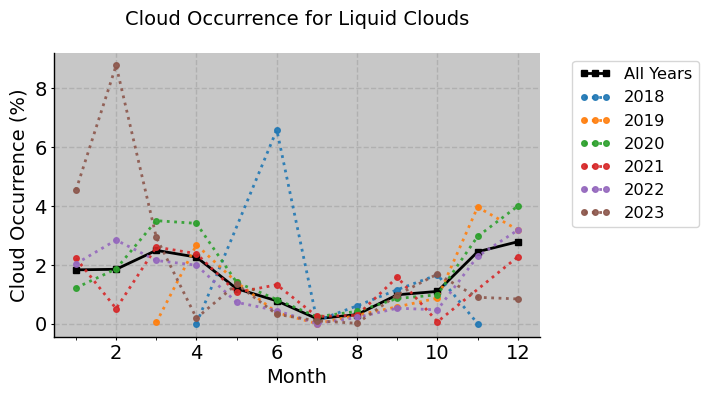

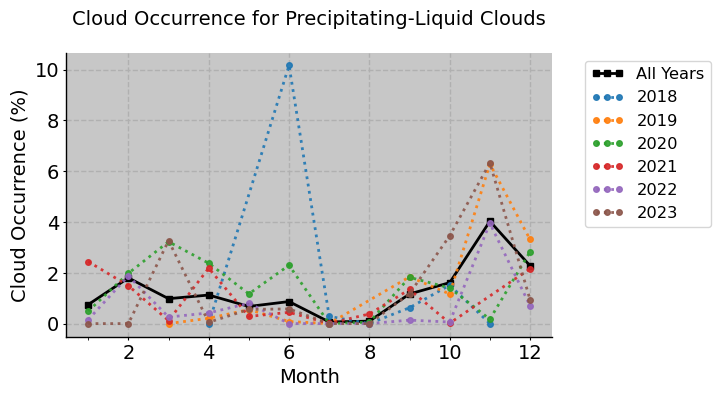

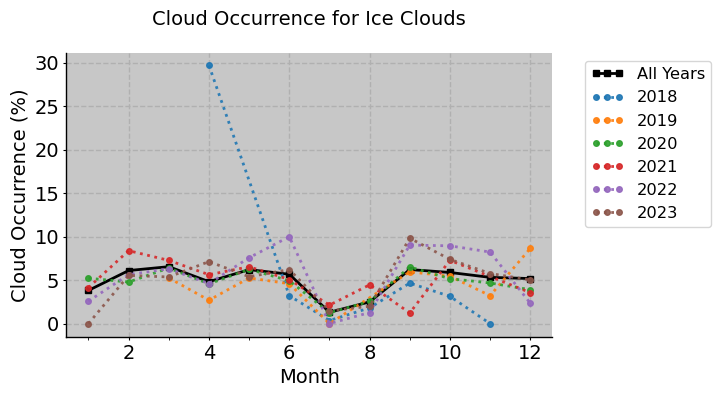

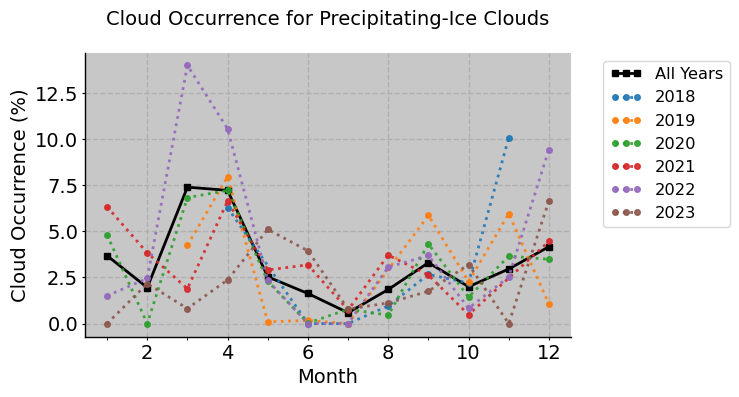

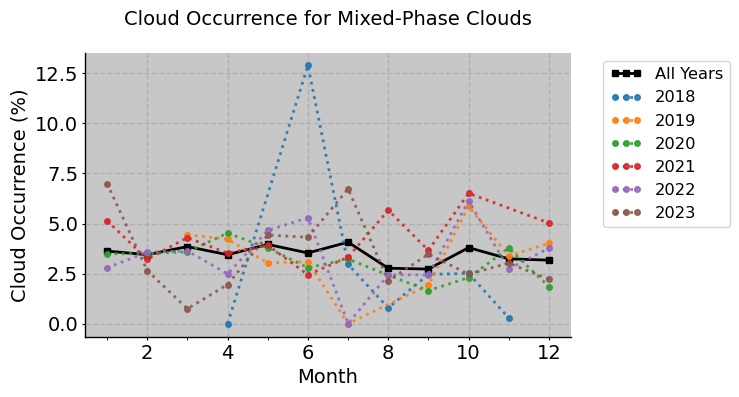

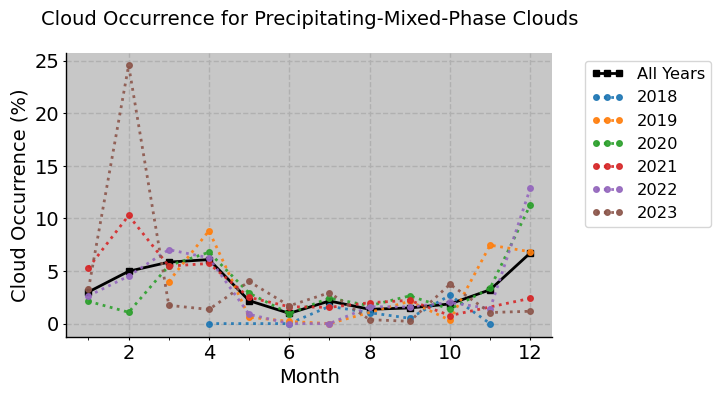

In [61]:
ds_occ_cba_single_layer

props = list(ds_prop_cba_single_layer.data_vars)
clouds = list(ds_ctp_cba.data_vars)[:-1]
years = np.unique(ds_prop['time'].dt.year)

for cloud in clouds:
    fig, ax = plt.subplots(figsize=(6,4))
    
    freq_occ_tot = ds_ctp_cba_single_layer[cloud].groupby('time.month').mean()*100
    ax.plot(freq_occ_tot['month'], 
                freq_occ_tot, 
                label='All Years', 
                marker='s',
                markersize=4, 
                color = 'black', 
                linestyle='-',
                linewidth=2)
    for y in years:
        # plot a comparison between PBA and CBA methods for each property p
        freq_occ = ds_ctp_cba_single_layer[cloud].sel(time=str(y)).groupby('time.month').mean()*100
        # freq_occ = ds_ctp_cba_single_layer[cloud].sel(time=str(y)).resample(time='1M').mean()*100

        ax.plot(freq_occ['month'], 
                freq_occ, 
                label=f'{y}', 
                marker='o',
                markersize=4, 
                linestyle=':',
                linewidth=2,
                alpha=0.9,
                ) 
    ax.set_title(f'Cloud Occurrence for {cloud} Clouds')
    ax.set_xlabel('Month')
    ax.set_ylabel('Cloud Occurrence (%)')
    # let legend outside the plot on right side
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    # add more tickers on x-axis
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True) 
    fig.savefig(os.path.join(figure_path, f'cloud_occurrence_{cloud}_CBA_by_years.png'), dpi=300, bbox_inches='tight')
    with open(os.path.join(figure_path, f'cloud_occurrence_{cloud}_CBA_by_years.pkl'), 'wb') as f:
        pickle.dump(fig, f)
    plt.show()


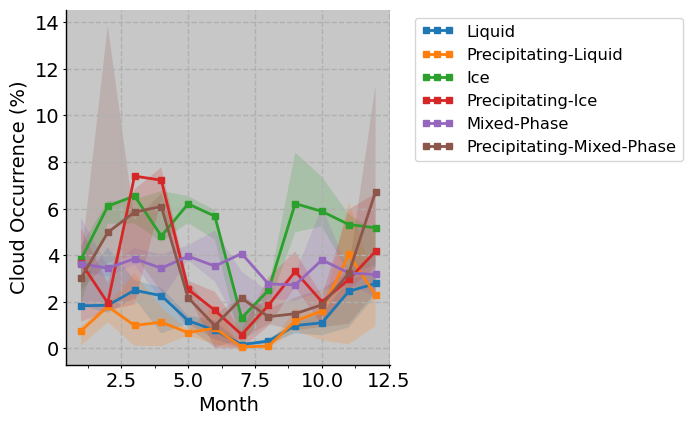

In [21]:
ds_occ_cba_single_layer

props = list(ds_prop_cba_single_layer.data_vars)
clouds = list(ds_ctp_cba.data_vars)[:-1]
years = np.unique(ds_prop_cba_single_layer['time'].dt.year)

fig, ax = plt.subplots(figsize=(4,5))
for cloud in clouds:
    
    freq_occ_tot = ds_ctp_cba_single_layer[cloud].groupby('time.month').mean()*100
    ax.plot(freq_occ_tot['month'], 
                freq_occ_tot, 
                label=f"{cloud}", 
                marker='s',
                markersize=4, 
                # color = 'black', 
                linestyle='-',
                linewidth=2)
    
    year_freqs = np.zeros((12, len(years)))

    for i, y in enumerate(years):
        # plot a comparison between PBA and CBA methods for each property p
        freq_occ = ds_ctp_cba_single_layer[cloud].sel(time=str(y)).groupby('time.month').mean()*100
        year_freqs[:, i] = freq_occ.reindex(month=np.arange(1,13), fill_value=np.nan).values
        # freq_occ = ds_ctp_cba_single_layer[cloud].sel(time=str(y)).resample(time='1M').mean()*100

    std_freq = np.nanstd(year_freqs, axis=1)
    q25_freq = np.nanpercentile(year_freqs, 25, axis=1)
    q75_freq = np.nanpercentile(year_freqs, 75, axis=1)
    ax.fill_between(freq_occ['month'], 
                    q25_freq, 
                    q75_freq, 
                    # color='blue', 
                    alpha=0.2)
         
ax.set_xlabel('Month')
ax.set_ylabel('Cloud Occurrence (%)')
# let legend outside the plot on right side
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
# add more tickers on x-axis
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True) 
plt.show()


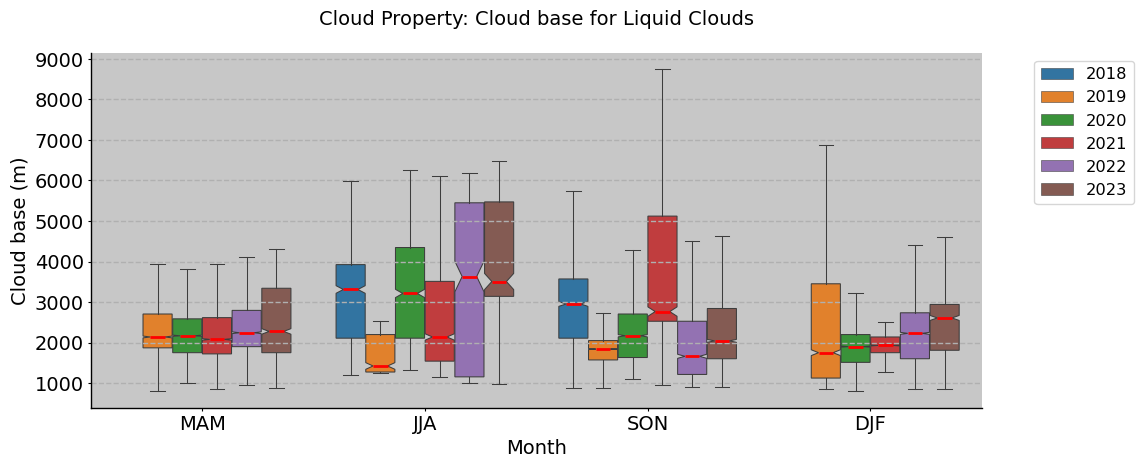

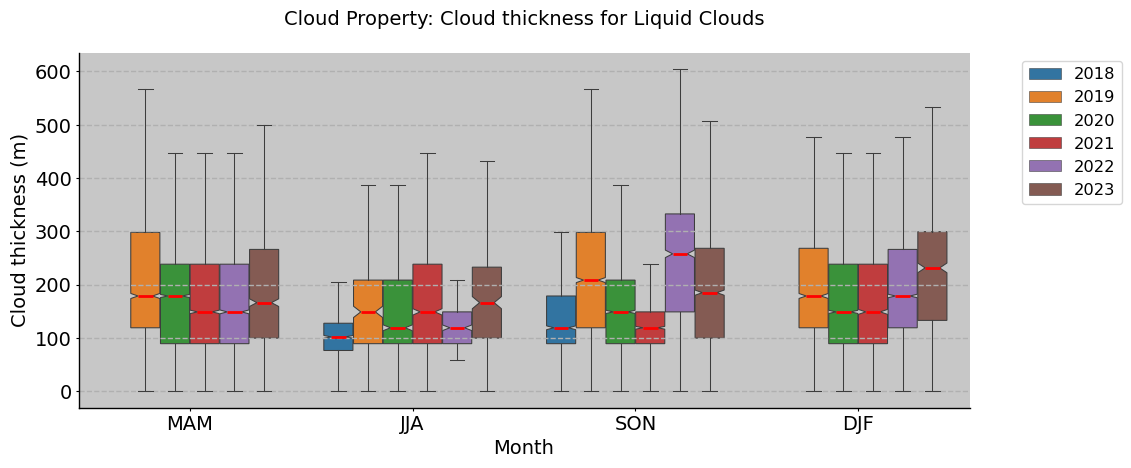

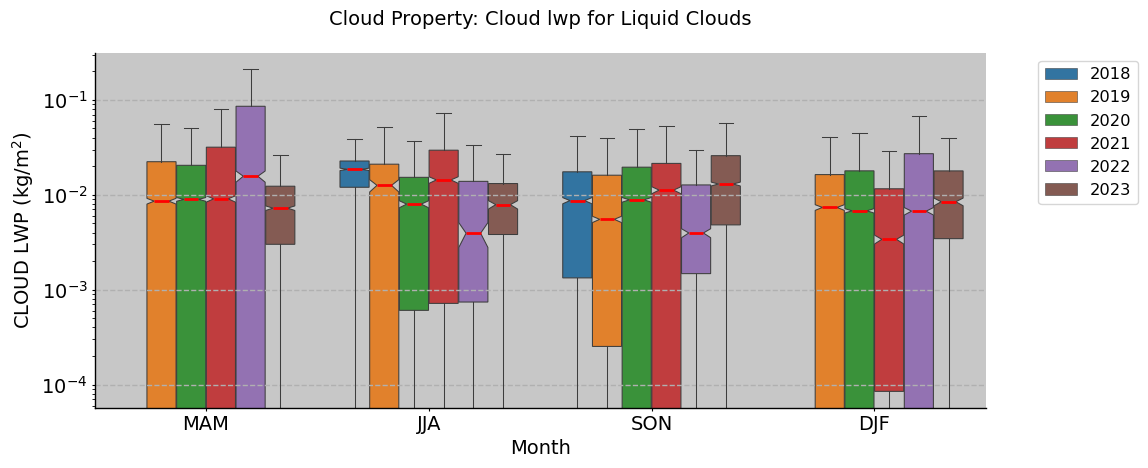

/tmp/ipykernel_872186/7138113.py:30: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


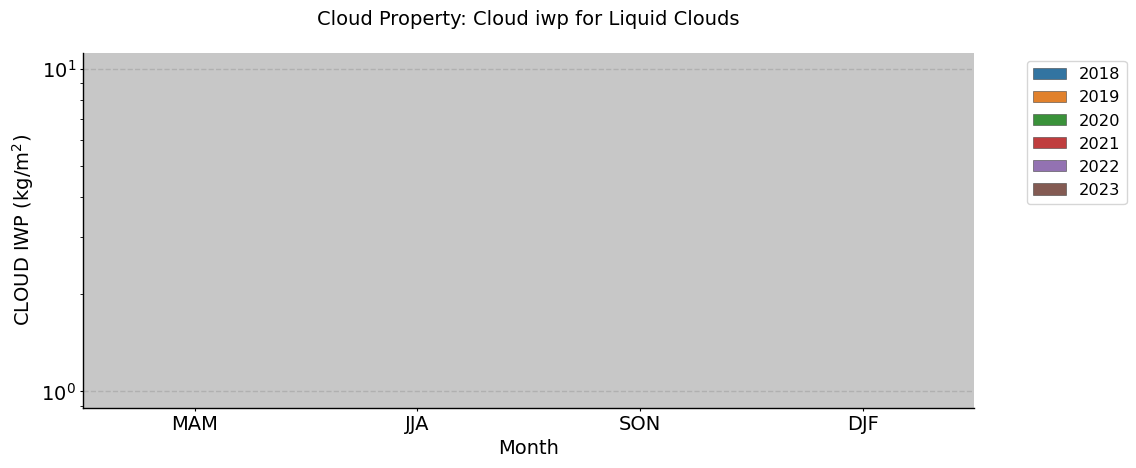

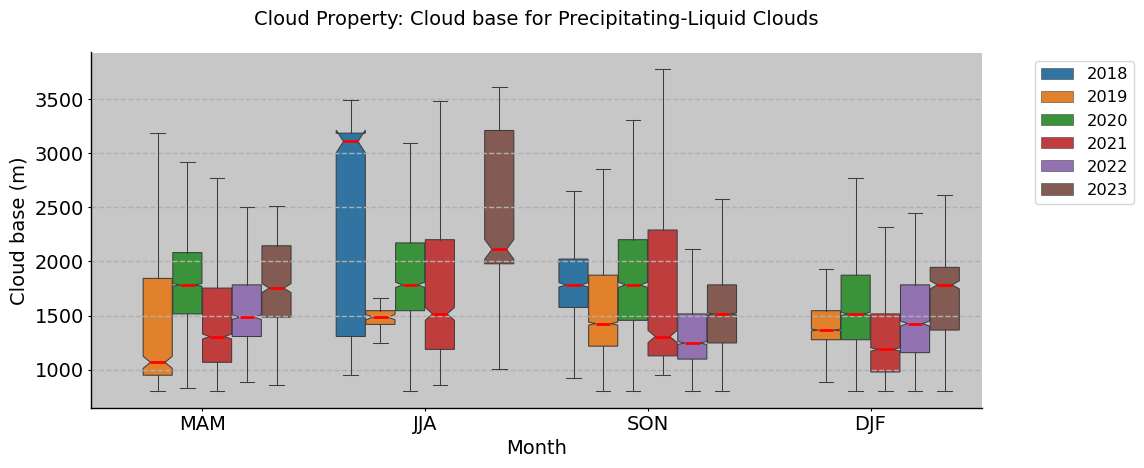

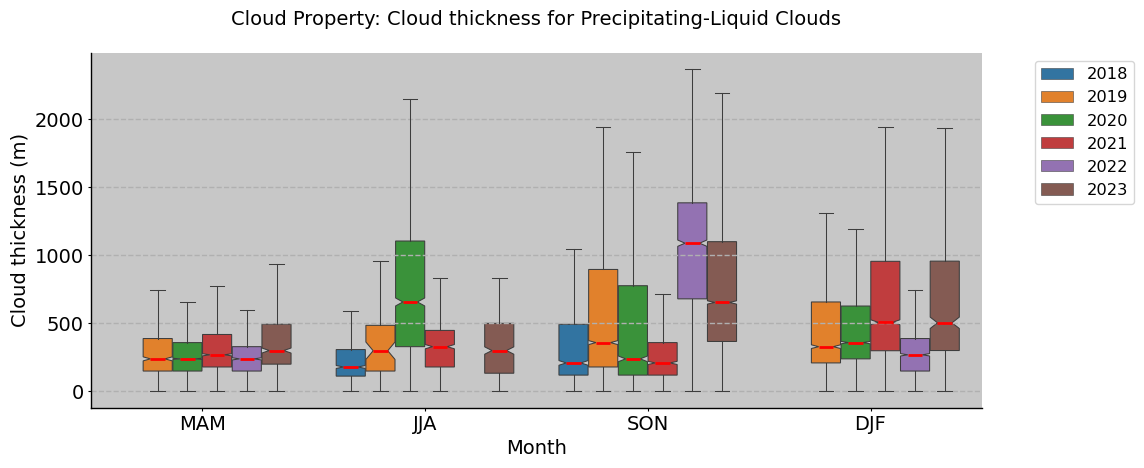

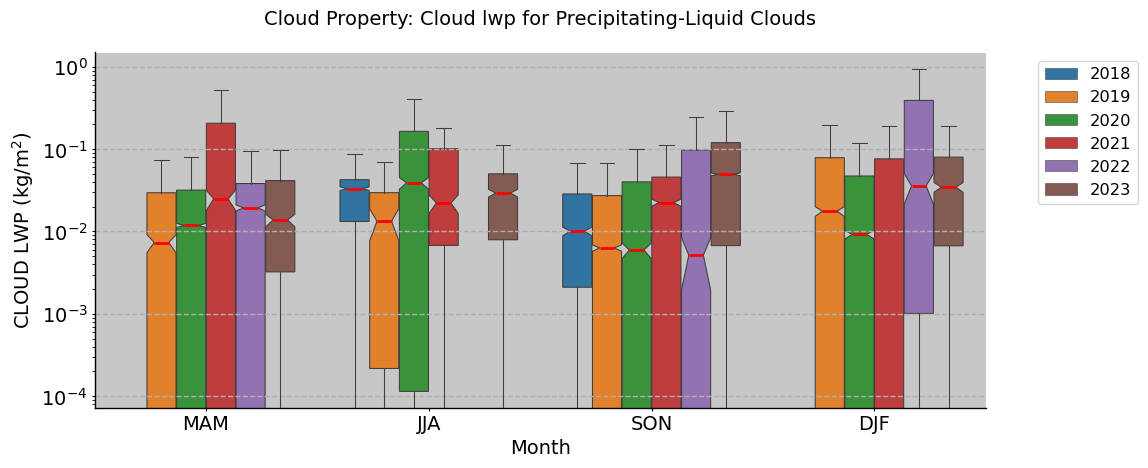

/tmp/ipykernel_872186/7138113.py:30: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


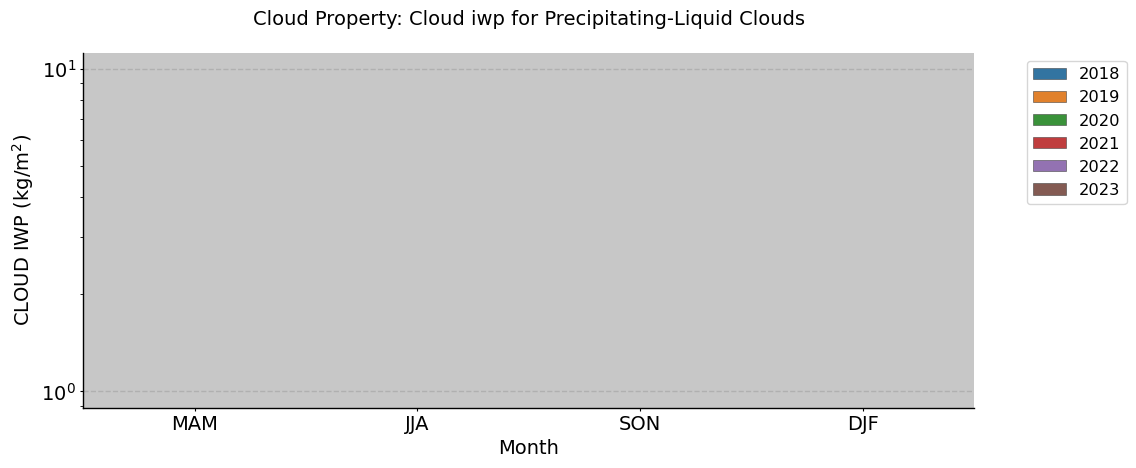

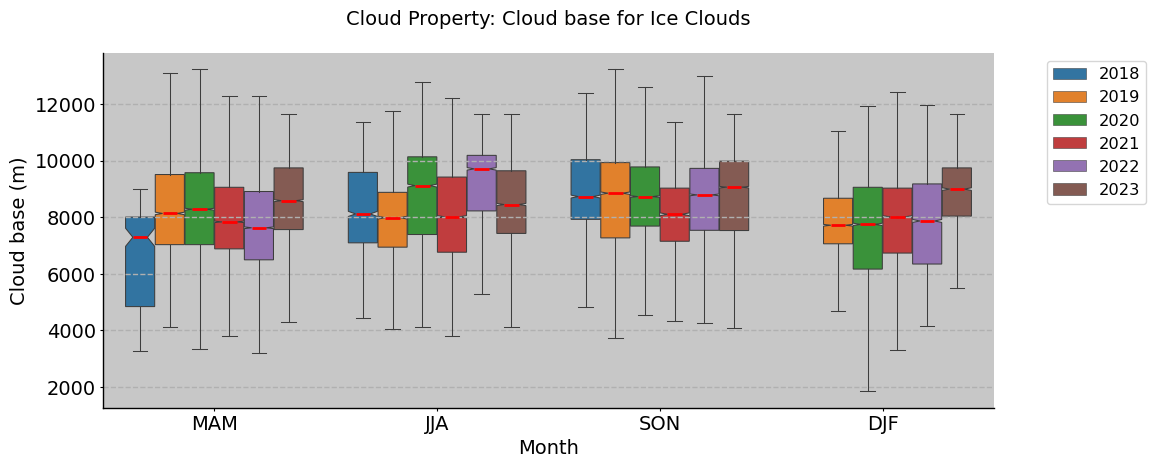

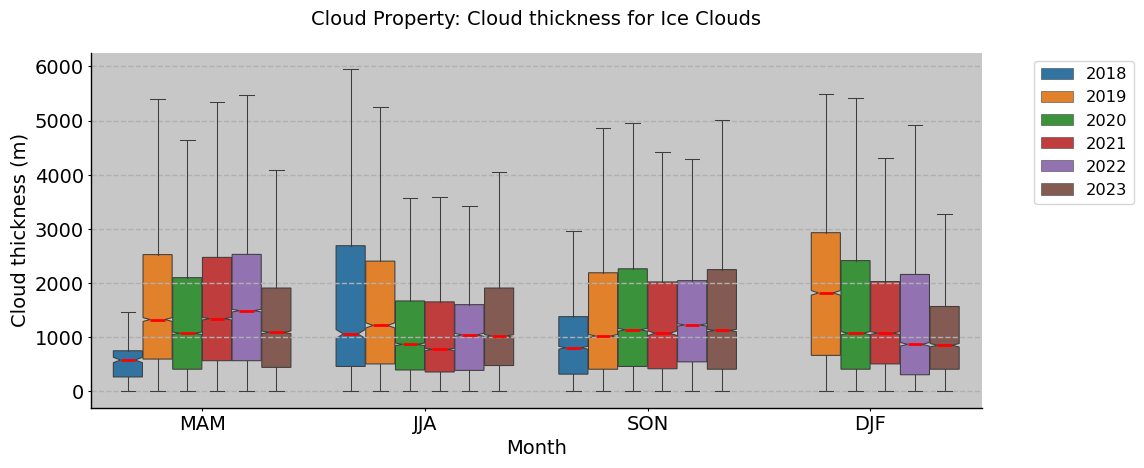

/tmp/ipykernel_872186/7138113.py:30: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


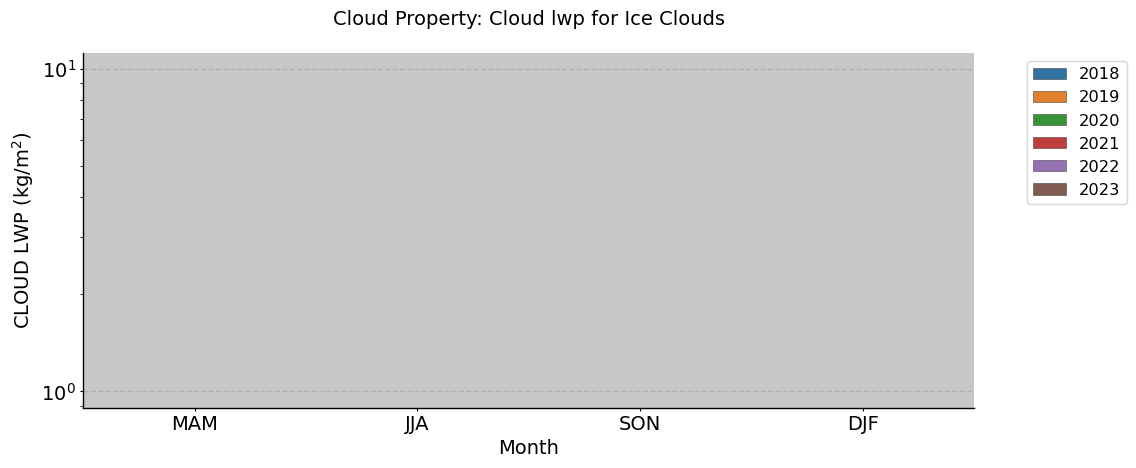

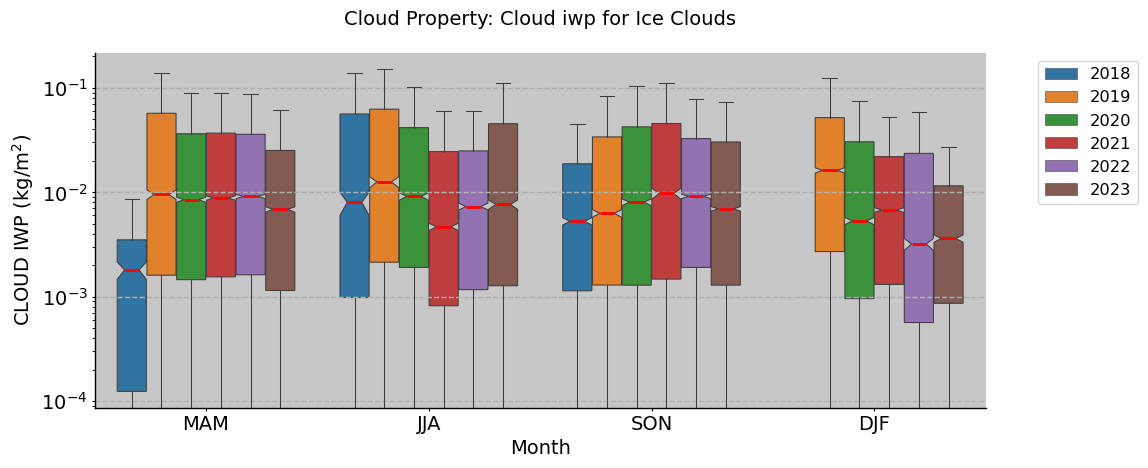

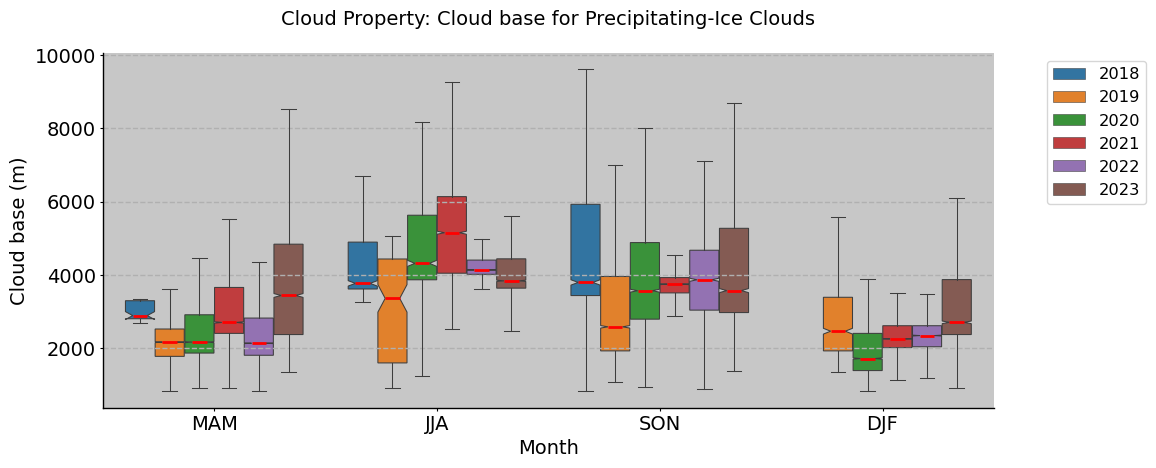

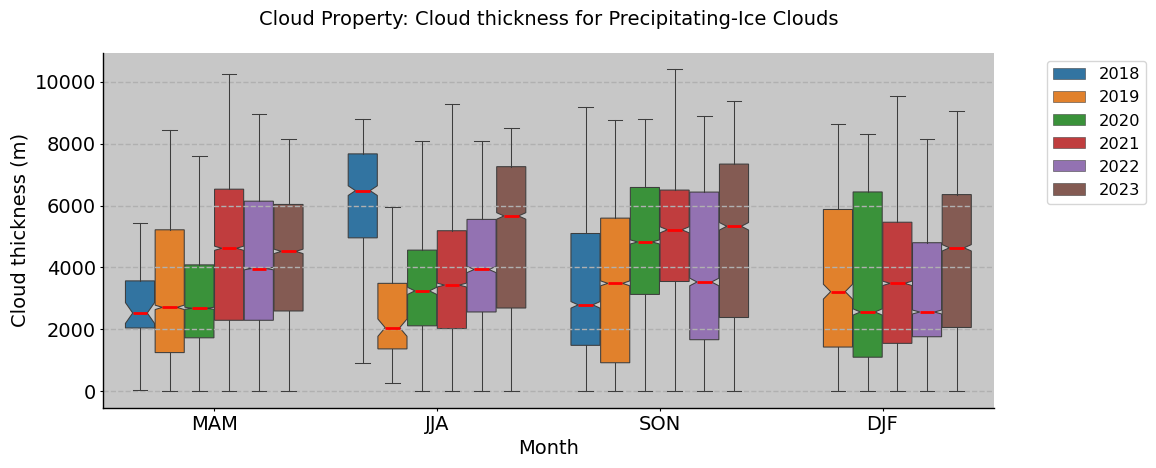

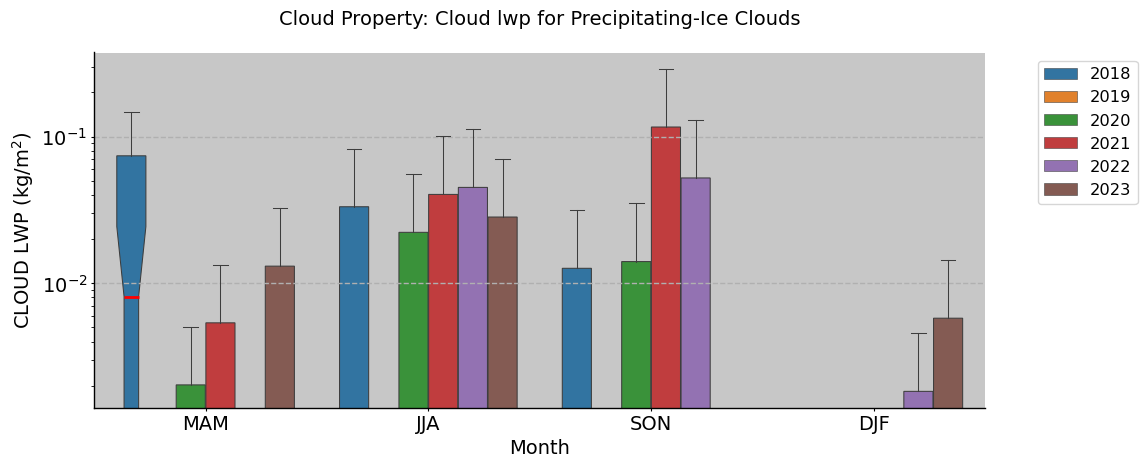

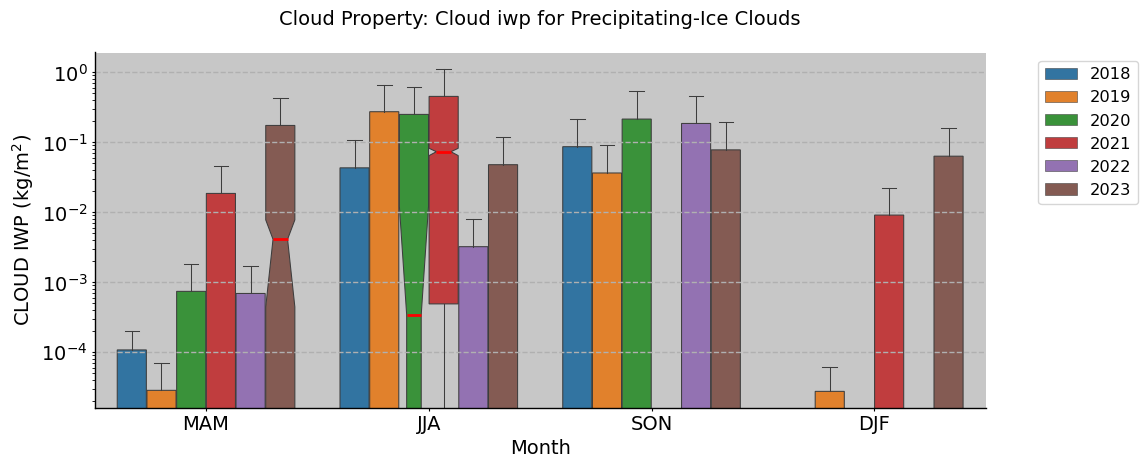

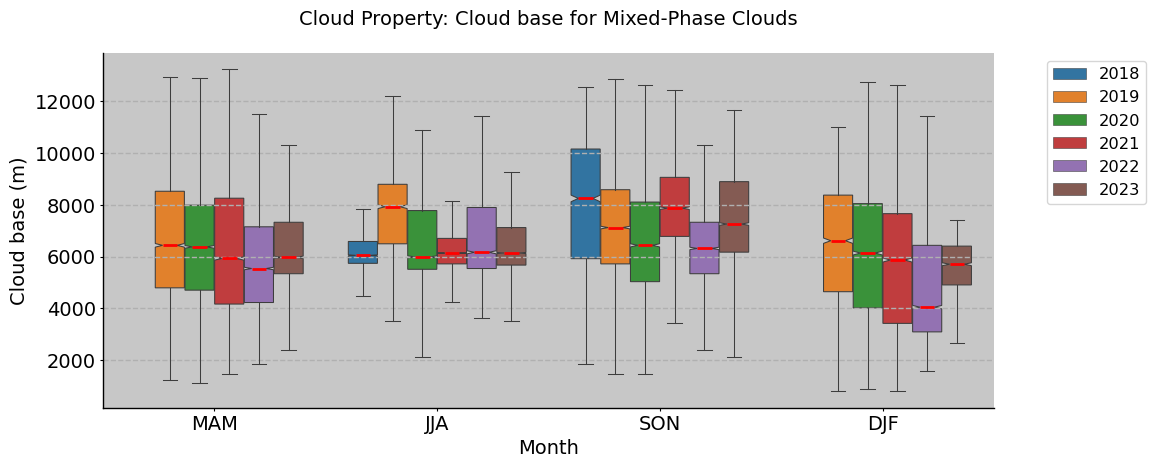

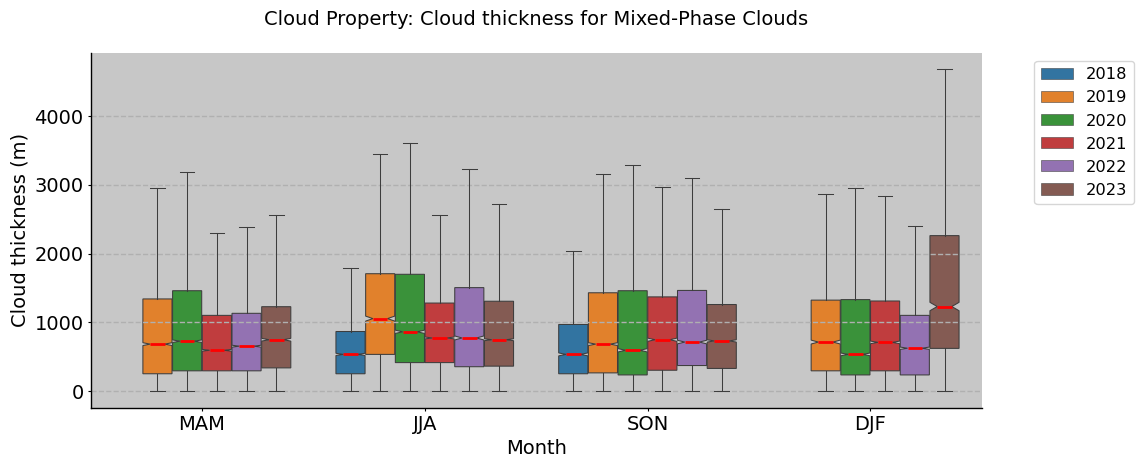

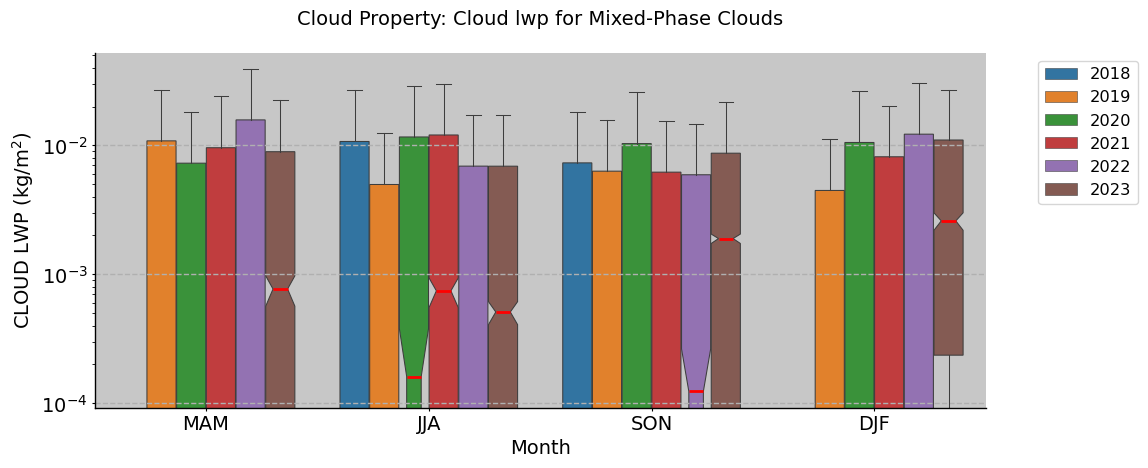

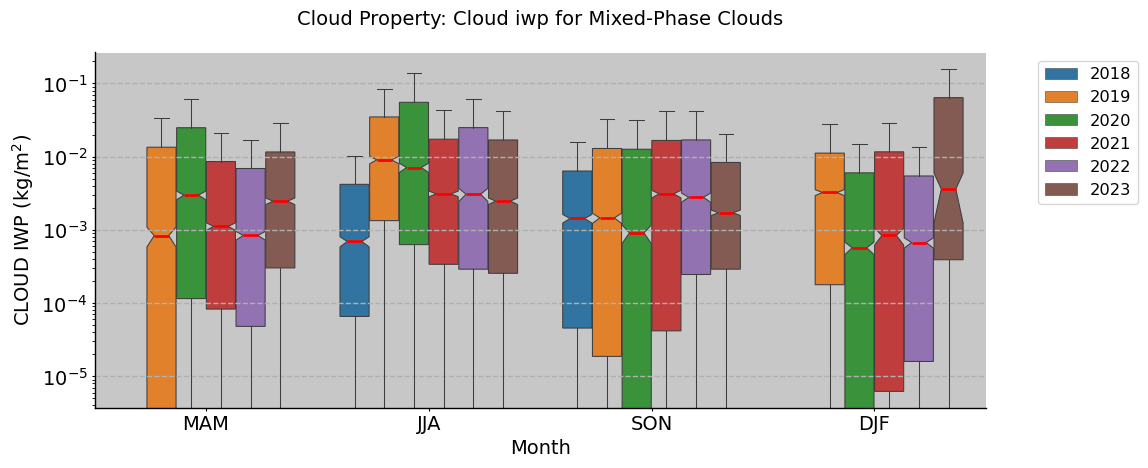

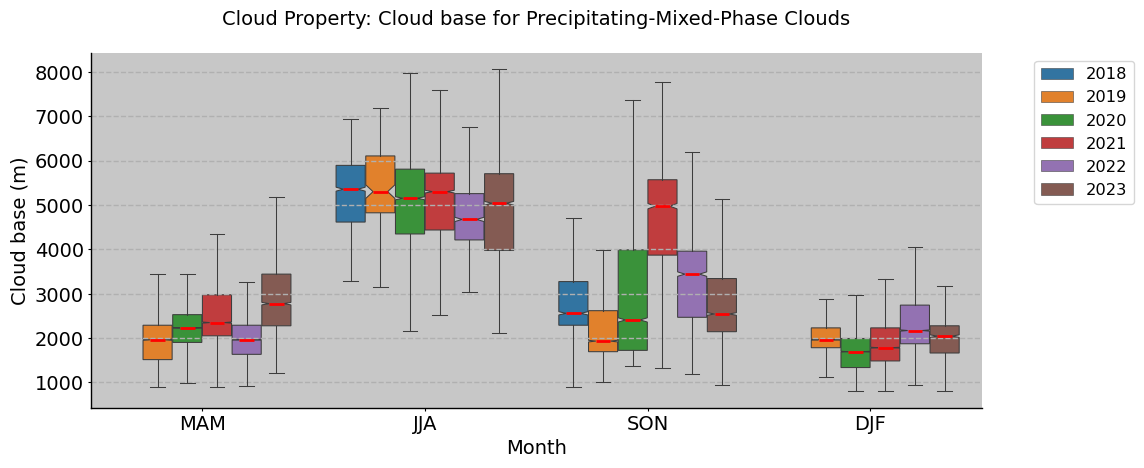

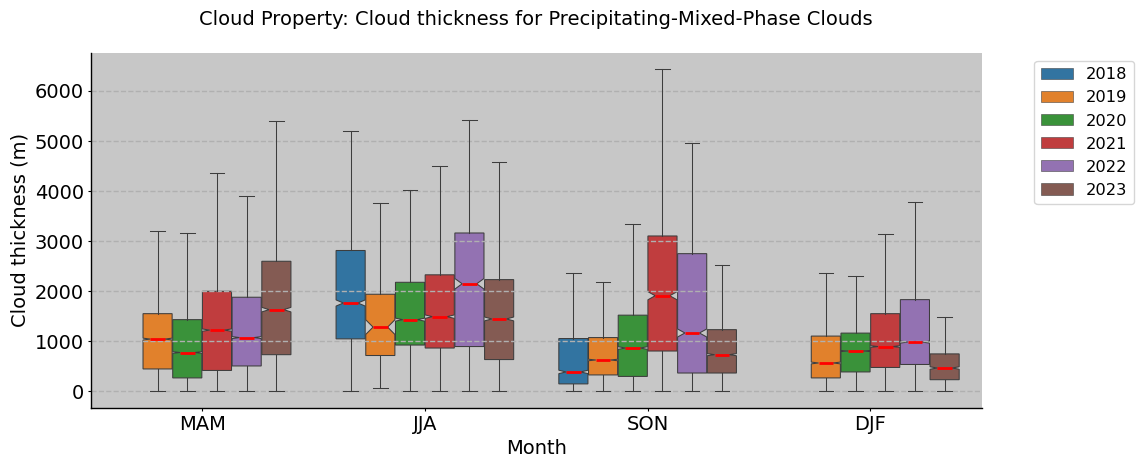

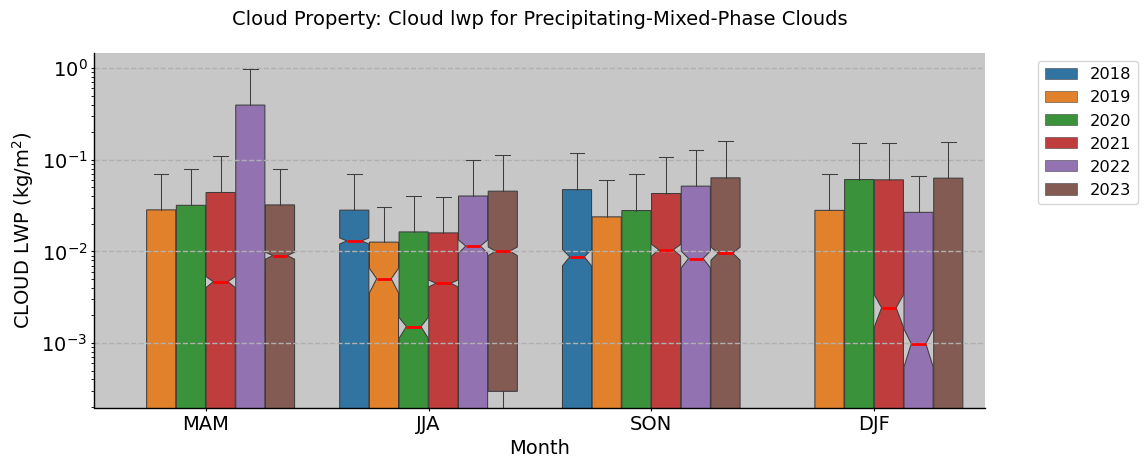

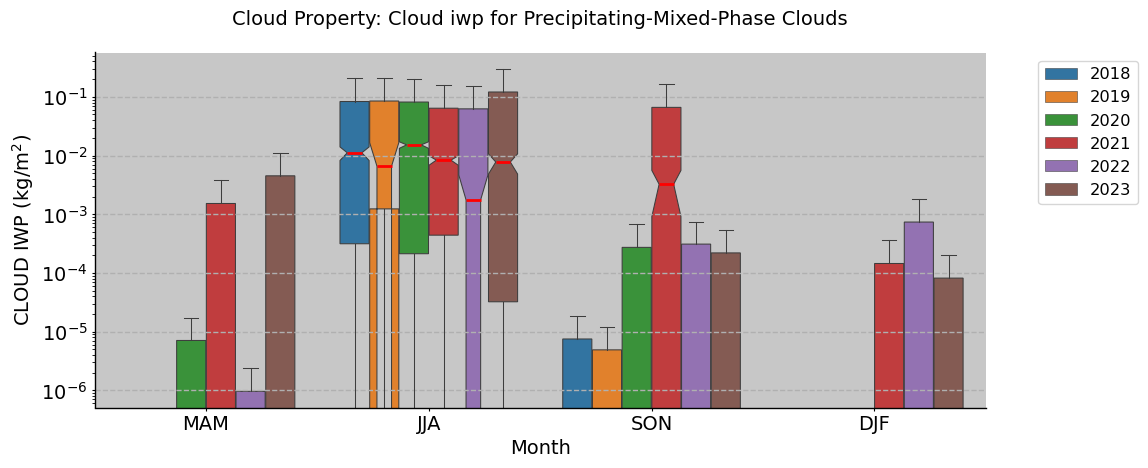

In [ ]:
props = list(ds_prop_cba_single_layer.data_vars)
clouds = list(ds_ctp_cba.data_vars)[:-1]
years = np.unique(ds_prop['time'].dt.year)
for cloud in clouds:
    for p in props:
        # plot a comparison between PBA and CBA methods for each property p
        # Make year a coordinate of ds_prop_cba_single_layer
        ds_prop_cba_single_layer = ds_prop_cba_single_layer.assign_coords(years=ds_prop_cba_single_layer['time'].dt.year,
                                                                            month=ds_prop_cba_single_layer['time'].dt.month,
                                                                            season=ds_prop_cba_single_layer['time'].dt.season
                                                                            ).compute()
        
        ds_prop_cloud = ds_prop_cba_single_layer.where(ds_ctp_cba_single_layer[cloud] == 1.)
        
        fig, ax = plt.subplots(figsize=(11,5))
        #make a boxplot with years as a hue
        # remove outliers from the boxplot
        sns.boxplot(x='season', y=p, 
                    hue='years',
                    data=ds_prop_cloud.to_dataframe().reset_index(),
                    notch=True,
                    # boxprops={"facecolor": (.3, .5, .7, .5)},
                    linewidth=.75,
                    medianprops={"color": "r", "linewidth": 2}, 
                    showfliers=False,
                    ax=ax)
        ax.set_title(f'Cloud Property: {p.replace("_", " ").capitalize()} for {cloud} Clouds')
        ax.set_xlabel('Month')
        if p == 'cloud_lwp' or p == 'cloud_iwp':
            ax.set_yscale('log')
            ax.set_ylabel(p.replace('_', ' ').upper() + r' (kg/m$^2$)')
        else:
            ax.set_ylabel(p.replace('_', ' ').capitalize() + ' (m)')
        #move legend outside the plot
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        # remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.show()


In [5]:
# Read pickle files with the figures and show them
methods = ['CBA', 'PBA']
dic_figures = {}
pickle_files = glob.glob(os.path.join(figure_path, f'comparison*.pkl'))
for file in pickle_files:
    with open(file, 'rb') as f:
        dic_figures[file] = pickle.load(f)

plt.close('all')

In [7]:
dic_figures.keys()

dict_keys(['/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_figures/comparison_mixed_ice_CBA.pkl', '/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_figures/comparison_mixed_ice_PBA.pkl'])

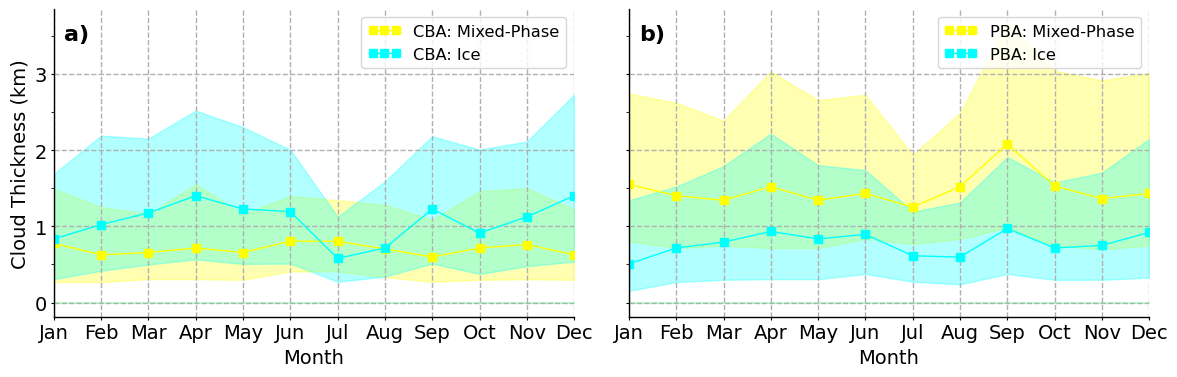

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4), gridspec_kw={'width_ratios': [1, 1]}, sharey=True)
for i, met in enumerate(methods):
    fig_met = dic_figures[os.path.join(figure_path, f'comparison_mixed_ice_{met}.pkl')]
    for ax in fig_met.axes:
        # move the content of the figure to the corresponding axis in the grid
        # plot everthing, lines and areas with the same style as in the original figure
        for line in ax.lines:
            axes[i].plot(line.get_xdata(), line.get_ydata(), 
                        label=line.get_label(),
                        marker=line.get_marker(),
                        markersize=line.get_markersize(),
                        linestyle=line.get_linestyle(),
                        linewidth=line.get_linewidth(),
                        color=line.get_color(),
                        alpha=line.get_alpha())
        for collection in ax.collections:
            if isinstance(collection, matplotlib.collections.PolyCollection):
                # get the vertices of the collection and plot them in the corresponding axis
                for path in collection.get_paths():
                    vertices = path.vertices
                    axes[i].fill_between(vertices[:,0], vertices[:,1], alpha=collection.get_alpha(), color=collection.get_facecolor()[0])
    # axes[i].set_title(f'{met} Method')
    # add text at the left-top corner with the letter of the dubplot as a, b, c,....
    axes[i].text(0.02, 0.95, f'{chr(97+i)})', transform=axes[i].transAxes, fontsize=16, fontweight='bold', va='top')
    
    axes[i].set_xlabel('Month')
    if i == 0:
        axes[i].set_ylabel('Cloud Thickness (km)')
    axes[i].legend().set_visible(False)
    # remove top and right spines
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    # white background 
    axes[i].set_facecolor('white')
    # legends
    axes[i].legend(loc='upper right', fontsize='small')
    # show all months in x-axis
    axes[i].set_xticks(np.arange(1,13,1))
    axes[i].set_xlim(1,12)
    axes[i].yaxis.set_minor_locator(AutoMinorLocator(2))
    # show month names in x-axis
    axes[i].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

fig.tight_layout()
fig.savefig(os.path.join(figure_path, f'comparison_mixed_ice_CBA_PBA_combined.png'), dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
pattern_list = [
                "*min_cloudp.nc",
                "*min_liquid_percentage.nc",
                "*min_ice_percentage.nc",
                "*min_rainp.nc",
                ]

parameter_names = {'min_liquid_percentage': 'Liquid Criteria',
                'min_ice_percentage': 'Ice Criteria',
                'min_cloudp': 'Cloud Criteria',
                'min_rainp': 'Rain Criteria'
                }

# For each pattern, read the corresponding pikle files with the figures of the sensitivity analysis and plot them in a grid with 5 rows and 4 columns. Each row will be the cloud property and each column will be the pattern.

# First read the pickle files and store them in a dictionary with the pattern as key and the figure as value
props = ['cloud_occurrence', 'cloud_base', 'cloud_thickness', 'cloud_lwp', 'cloud_iwp']
dic_figures_sensitivity = {pattern[1:-3]: [] for pattern in pattern_list}

for pattern in pattern_list:
    for p in props:
        if p == 'cloud_occurrence':
            pickle_file = glob.glob(os.path.join(figure_path, f'{p}*_{pattern[1:-3]}_*sensitivity_analysis.pkl'))
        else: 
            pickle_file = glob.glob(os.path.join(figure_path, f'cloud_properties_{p}_{pattern[1:-3]}_sensitivity_analysis.pkl'))
        
        if pickle_file:
            with open(pickle_file[0], 'rb') as f:
                dic_figures_sensitivity[pattern[1:-3]].append(pickle.load(f))
        else:
            print(f"No pickle file found for pattern {pattern} and property {p}")
plt.close('all')

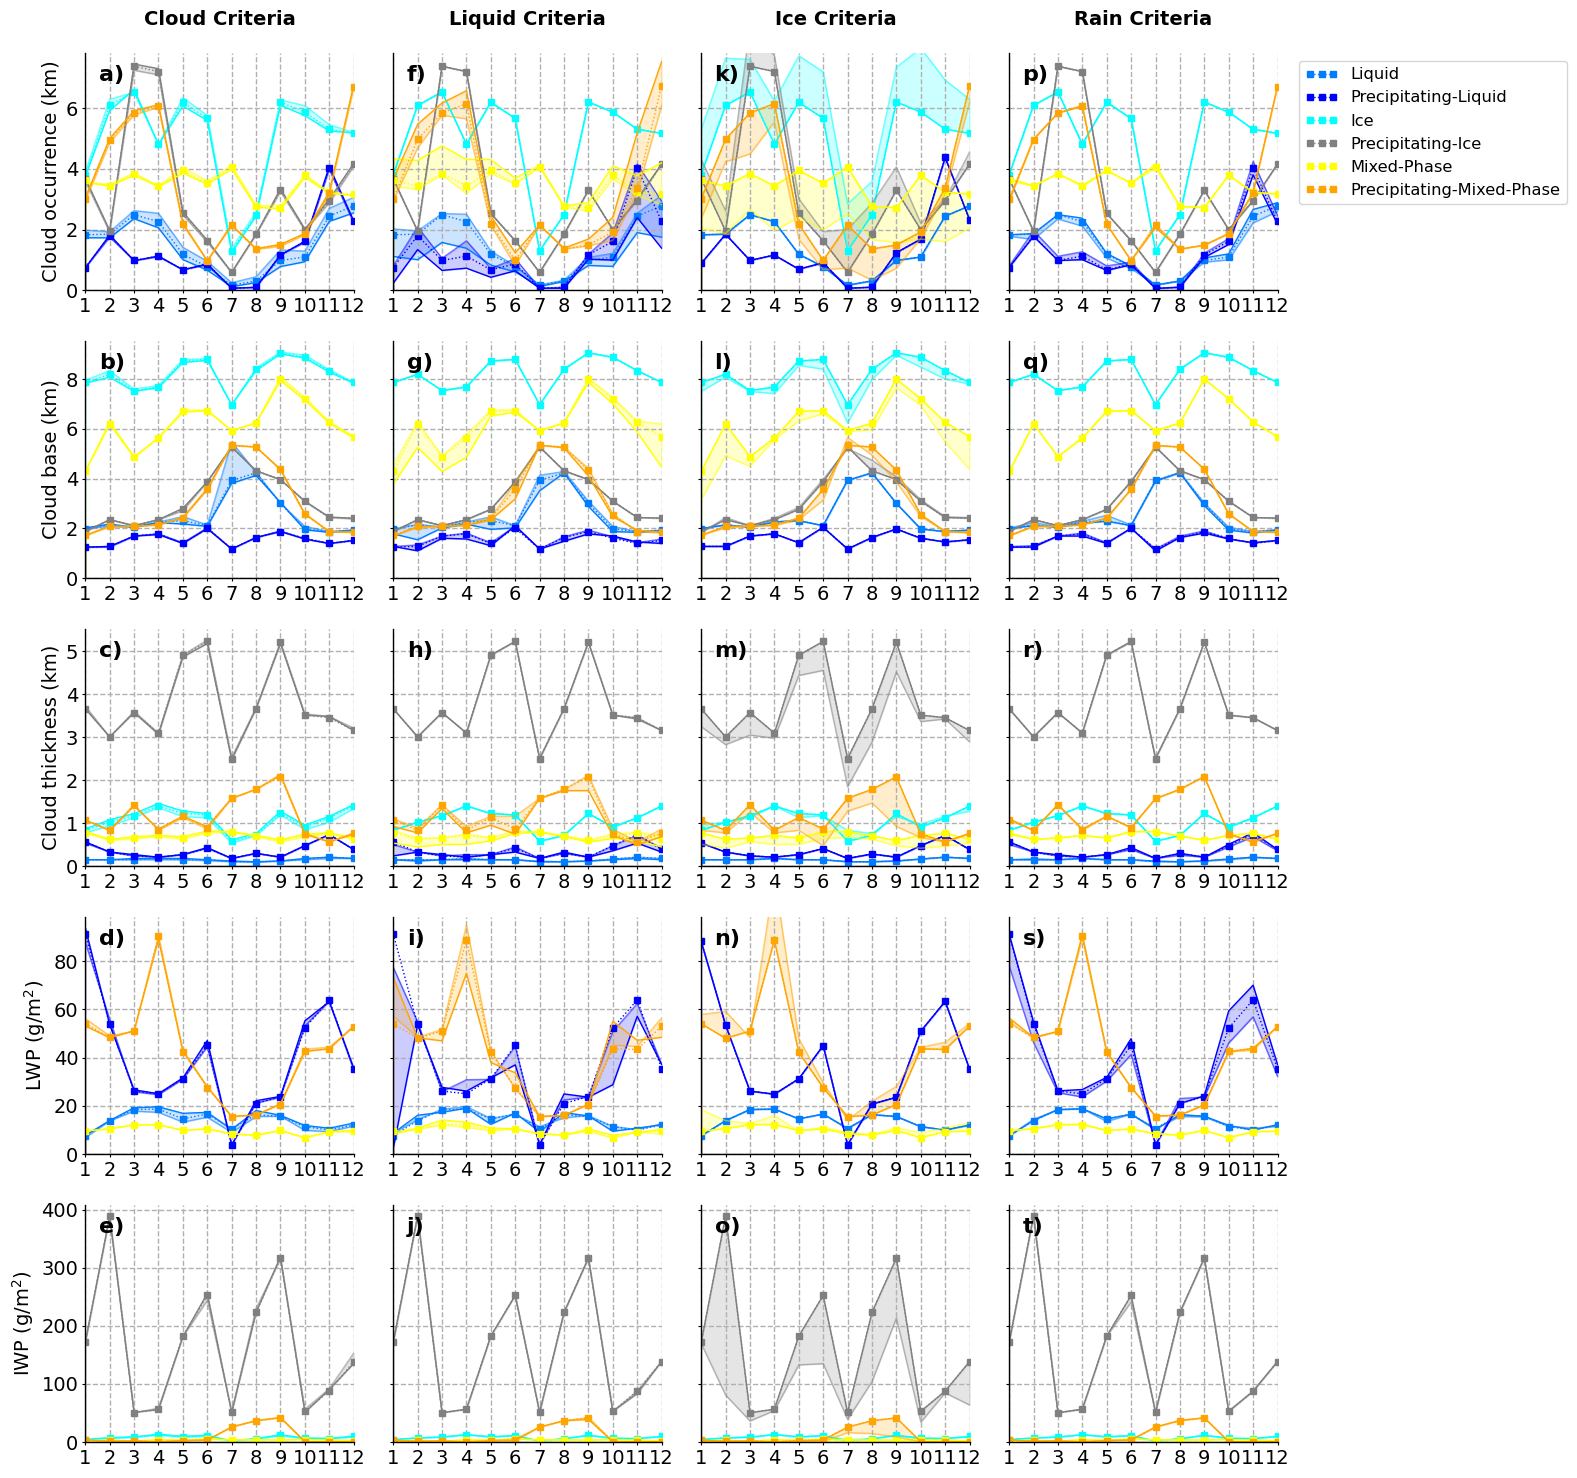

In [78]:
# For each pattern, read the corresponding pikle files with the figures of the sensitivity analysis and plot them in a grid with 5 rows and 4 columns. Each row will be the cloud property and each column will be the pattern.
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(16,15), gridspec_kw={'width_ratios': [1, 1, 1, 1]}, sharey='row')
for j, pattern in enumerate(pattern_list):
    for i, p in enumerate(props):
    
        fig_p = dic_figures_sensitivity[pattern[1:-3]][i]
        ax = axes[i, j]
        for ax_p in fig_p.axes:
            # move the content of the figure to the corresponding axis in the grid
            # plot everthing, lines and areas with the same style as in the original figure
            for line in ax_p.lines:
                ax.plot(line.get_xdata(), line.get_ydata(), 
                        label=line.get_label(),
                        marker=line.get_marker(),
                        markersize=line.get_markersize(),
                        linestyle=line.get_linestyle(),
                        linewidth=line.get_linewidth(),
                        color=line.get_color(),
                        alpha=line.get_alpha())
            
            # plot the areas with the same style as in the original figure
            # There are less lines for p = 'cloud_lwp' and p = 'cloud_iwp', dont mess with the order of the lines and areas, because they are plotted in a specific order in the original figure to show the confidence intervals correctly
            for collection in ax_p.collections:
                if isinstance(collection, matplotlib.collections.PolyCollection):
                    # get the vertices of the collection and plot them in the corresponding axis
                    for path in collection.get_paths():
                        vertices = path.vertices
                        ax.fill_between(vertices[:,0], vertices[:,1], alpha=collection.get_alpha(), color=collection.get_facecolor()[0])
        # add text at the left-top corner with the letter of the dubplot as a, b, c,....
        ax.text(0.05, 0.95, f'{chr(97 + i + j*5)})', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')               
        if i == 0:
            ax.set_title(f'{parameter_names[pattern[1:-3]]}', fontweight='bold')
        
        if j == 0 and (p == 'cloud_lwp' or p == 'cloud_iwp'):
            ax.set_ylabel(p.split('_')[1].replace('_', ' ').upper() + r' (g/m$^2$)')
        elif j == 0:
            ax.set_ylabel(p.replace('_', ' ').capitalize() + ' (km)')
        # remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # white background 
        ax.set_facecolor('white')
        # # legends
        if i == 0 and j == 3:
            # shows legend outside the plot on the right side
            ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small')
        # show all months in x-axis
        ax.set_ylim(0, None)
        #set x-axis ticks to be every month
        ax.set_xticks(range(1, 13))
        ax.set_xlim(1, 12)
        # ax.set_xticklabels([f'{i}' for i in range(1, 13)])

fig.tight_layout()
fig.savefig(os.path.join(figure_path, f'sensitivity_analysis_combined.png'), dpi=400, bbox_inches='tight')
plt.show()

In [40]:
# Read pickle files with the figures and show them
clouds = ['Liquid', 'Precipitating-Liquid', 'Ice', 'Precipitating-Ice', 'Mixed-Phase', 'Precipitating-Mixed-Phase']
dic_cloud_fig = {}

for cloud in clouds:
    pickle_file = glob.glob(os.path.join(figure_path, f'att_filter_influence_{cloud}.pkl'))
    if pickle_file:
        with open(pickle_file[0], 'rb') as f:
            dic_cloud_fig[cloud] = pickle.load(f)
    else:
        print(f"No pickle file found for cloud {cloud}")

plt.close('all')

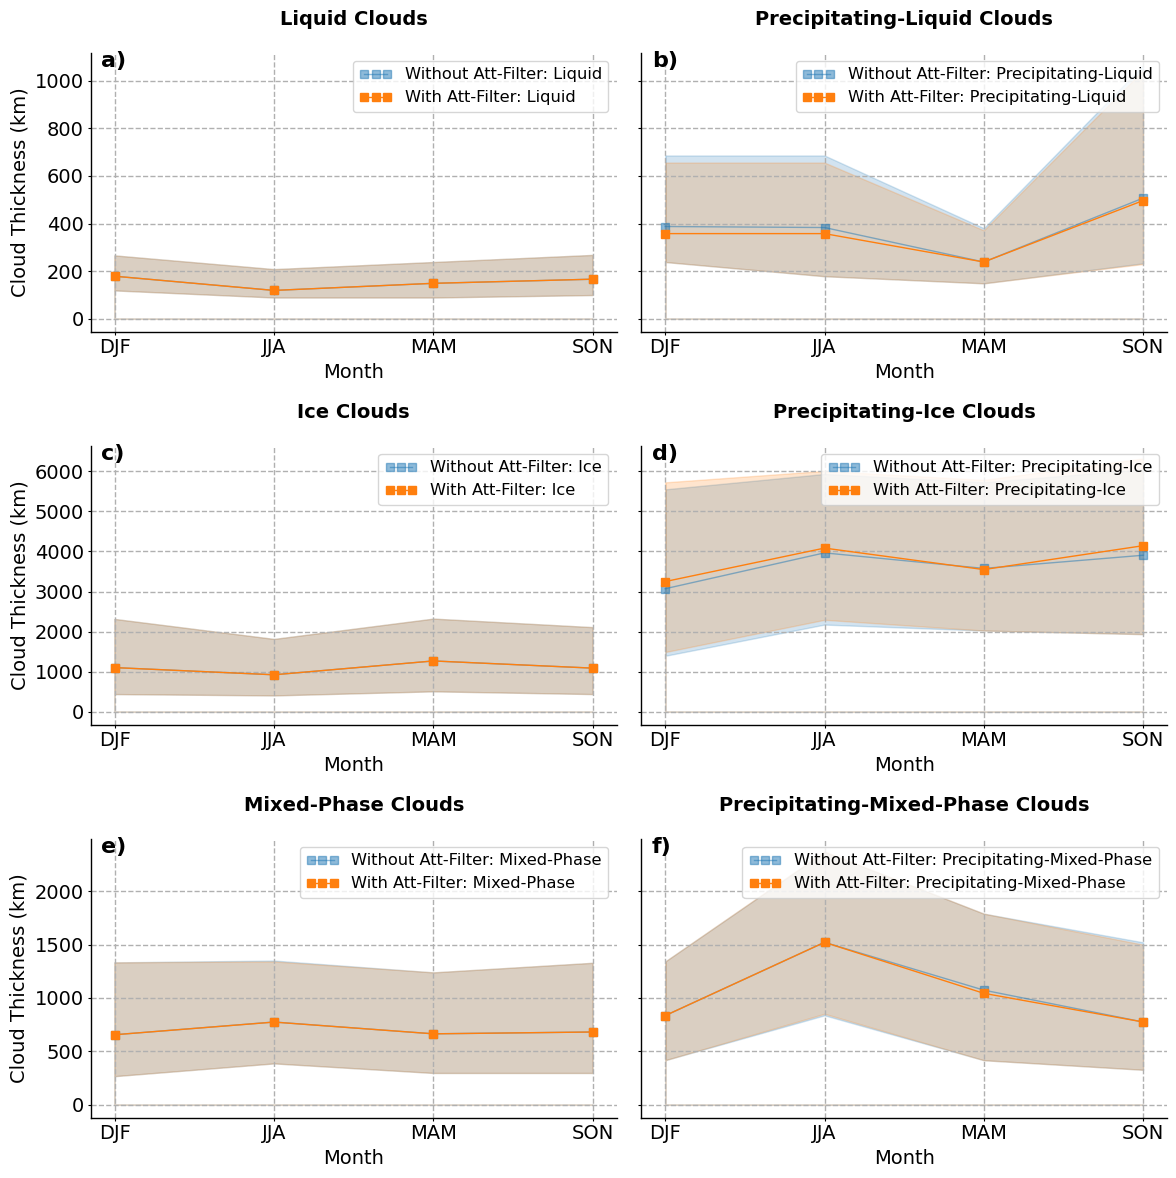

In [60]:
# Plot all clouds in the same figure 6 subplots with 3 rows and 3 columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12,12), gridspec_kw={'width_ratios': [1, 1], 'height_ratios': [1, 1, 1]}, sharey='row')
for i, cloud in enumerate(clouds):
    ax = axes[i//2, i%2]
    fig_cloud = dic_cloud_fig[cloud]
    for ax_cloud in fig_cloud.axes:
        # move the content of the figure to the corresponding axis in the grid
        # plot everthing, lines and areas with the same style as in the original figure
        for line in ax_cloud.lines:
            ax.plot(line.get_xdata(), line.get_ydata(), 
                    label=line.get_label(),
                    marker=line.get_marker(),
                    markersize=line.get_markersize(),
                    linestyle=line.get_linestyle(),
                    linewidth=line.get_linewidth(),
                    color=line.get_color(),
                    alpha=line.get_alpha())
        for collection in ax_cloud.collections:
            if isinstance(collection, matplotlib.collections.PolyCollection):
                # get the vertices of the collection and plot them in the corresponding axis
                for path in collection.get_paths():
                    vertices = path.vertices
                    ax.fill_between(vertices[:,0], vertices[:,1], alpha=collection.get_alpha(), color=collection.get_facecolor()[0])

        for other_ax in ax_cloud.figure.axes:
            if other_ax is not ax_cloud and other_ax.get_shared_x_axes().joined(other_ax, ax_cloud):
                ax2 = ax.twinx()

                for line in other_ax.lines:
                    ax2.plot(line.get_xdata(), line.get_ydata(),
                            label=line.get_label(),
                            marker=line.get_marker(),
                            markersize=line.get_markersize(),
                            linestyle=line.get_linestyle(),
                            linewidth=line.get_linewidth(),
                            color=line.get_color(),
                            alpha=line.get_alpha())

                ax2.set_ylabel('Attenuation Frequency (%)', color='red')
                ax2.tick_params(axis='y', labelcolor='red')
                ax2.set_ylim(0, None)


    # add text at the left-top corner with the letter of the dubplot as a, b, c,....
    ax.text(0.02, 0.95, f'{chr(97+i)})', transform=ax.transAxes, fontsize=16, fontweight='bold')
    ax.set_title(f'{cloud} Clouds' , fontweight='bold')
    ax.set_xlabel('Month')
    if i%2 == 0:
        ax.set_ylabel('Cloud Thickness (km)')
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # legends
    ax.legend(loc='upper right', fontsize='small')
    ax.set_facecolor('white')
    # show all months in x-axis
plt.tight_layout()
fig.savefig(os.path.join(figure_path, f'att_filter_influence_all_clouds.png'), dpi=400, bbox_inches='tight')
plt.show()  

In [64]:
# Read pickle files with the figures and show them
clouds = ['Liquid', 'Precipitating-Liquid', 'Ice', 'Precipitating-Ice', 'Mixed-Phase', 'Precipitating-Mixed-Phase']
dic_cloud_fig = {}

for cloud in clouds:
    pickle_file = glob.glob(os.path.join(figure_path, f'cloud_occurrence_{cloud}_CBA*.pkl'))
    if pickle_file:
        with open(pickle_file[0], 'rb') as f:
            dic_cloud_fig[cloud] = pickle.load(f)
    else:
        print(f"No pickle file found for cloud {cloud}")

plt.close('all')

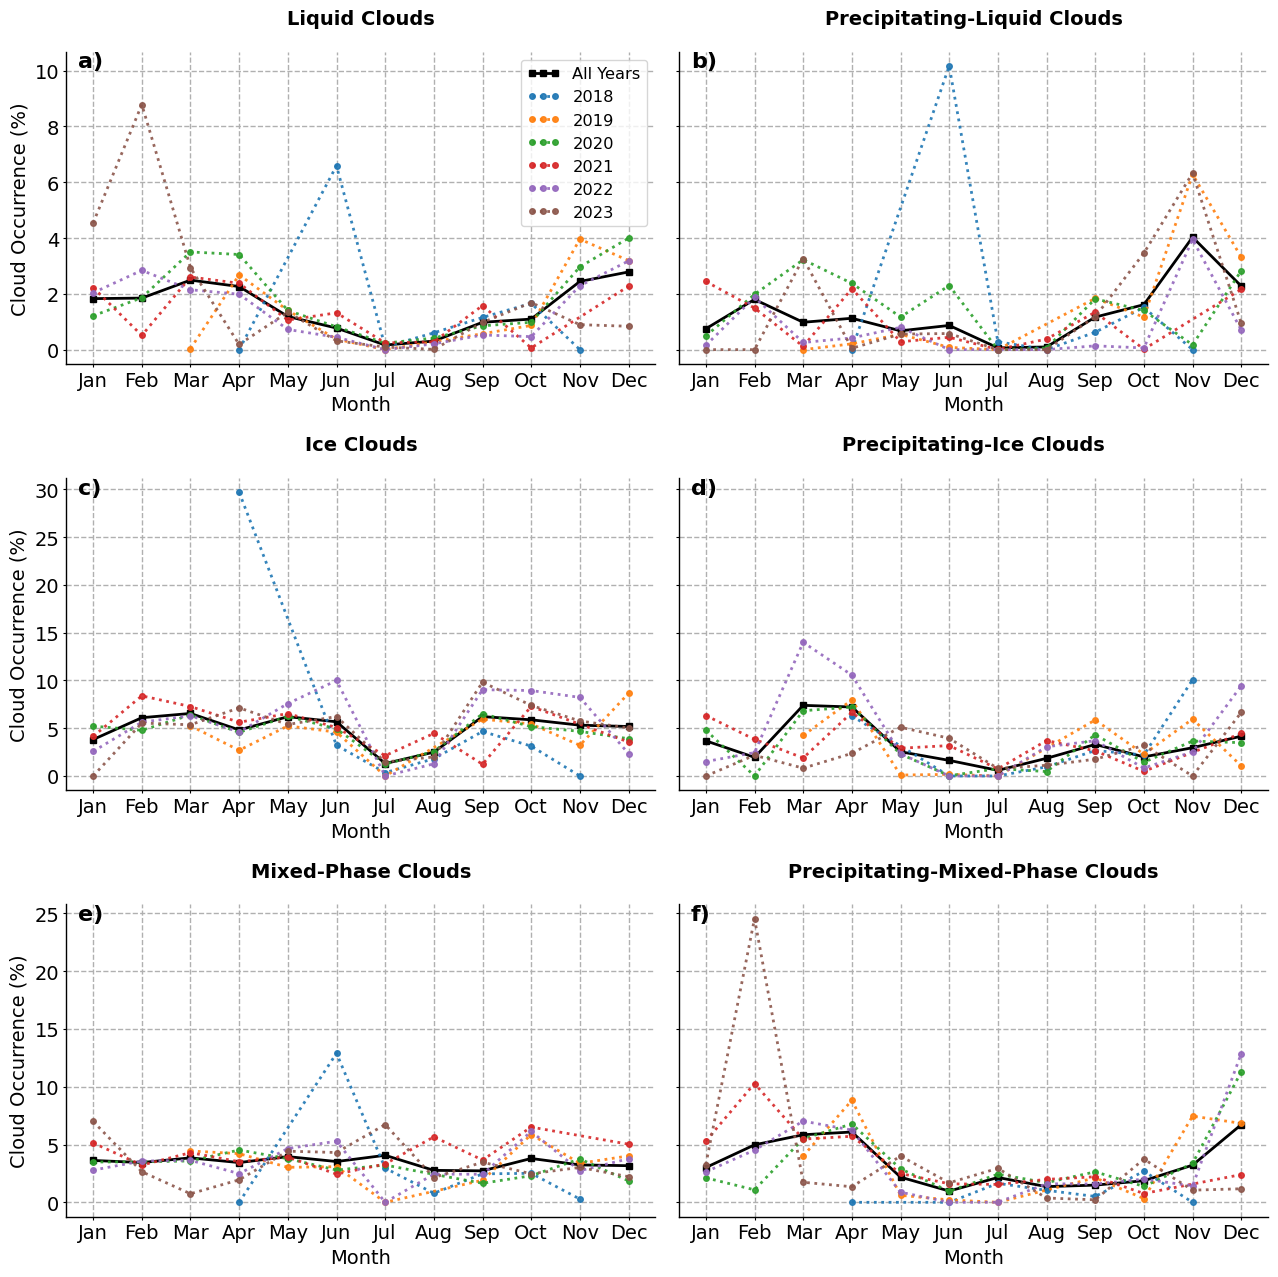

In [70]:
# Plot cloud occurence for each cloud type in the same figure with 6 subplots with 3 rows and 3 columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13,13), gridspec_kw={'width_ratios': [1, 1], 'height_ratios': [1, 1, 1]}, sharey='row')
for i, cloud in enumerate(clouds):
    ax = axes[i//2, i%2]
    fig_cloud = dic_cloud_fig[cloud]
    for ax_cloud in fig_cloud.axes:
        # move the content of the figure to the corresponding axis in the grid
        # plot everthing, lines and areas with the same style as in the original figure
        for line in ax_cloud.lines:
            ax.plot(line.get_xdata(), line.get_ydata(), 
                    label=line.get_label(),
                    marker=line.get_marker(),
                    markersize=line.get_markersize(),
                    linestyle=line.get_linestyle(),
                    linewidth=line.get_linewidth(),
                    color=line.get_color(),
                    alpha=line.get_alpha())
        for collection in ax_cloud.collections:
            if isinstance(collection, matplotlib.collections.PolyCollection):
                # get the vertices of the collection and plot them in the corresponding axis
                for path in collection.get_paths():
                    vertices = path.vertices
                    ax.fill_between(vertices[:,0], vertices[:,1], alpha=collection.get_alpha(), color=collection.get_facecolor()[0])
    
    # add text at the left-top corner with the letter of the dubplot as a, b, c,....
    ax.text(0.02, 0.95, f'{chr(97+i)})', transform=ax.transAxes, fontsize=16, fontweight='bold')
    ax.set_title(f'{cloud} Clouds' , fontweight='bold')
    ax.set_xlabel('Month')
    if i%2 == 0:
        ax.set_ylabel('Cloud Occurrence (%)')
    # remove top and right spines
    if i == 0:
        # show legend only in the first subplot
        ax.legend(loc='upper right', fontsize='small')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_facecolor('white')
    # show all months in x-axis
    ax.set_xticks(np.arange(1,13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
fig.savefig(os.path.join(figure_path, f'cloud_occurrence_all_clouds_CBA_by_years.png'), dpi=400, bbox_inches='tight')
plt.show()